# IE 5533 Project: Weather-aware Travel Itinerary Optimization

This notebook builds a weather-aware tourist itinerary optimizer for California coastal attractions. It loads Yelp attraction data, enriches it with weather and hotel information, predicts waiting times, simulates visit durations, and solves a route optimization problem with interactive map output.

Academic positioning: this project can be framed as a weather-aware multi-day Tourist Trip Design Problem (TTDP) with hotel selection. The general TTDP perspective is supported by the survey in [1] and the more recent systematic review in [2]. The overnight-accommodation extension follows the Orienteering Problem with Hotel Selection (OPHS), where hotel choices are part of the optimization and the hotel sequence can affect solution quality [3, 4].

Data-source note: attraction-side business information is derived from Yelp data and can also be supported by the Yelp Places API docs (`https://docs.developer.yelp.com/docs/places-intro`, `https://docs.developer.yelp.com/reference/v3_business_search`). Accommodation candidates are collected from OpenStreetMap through the Overpass API (`https://wiki.openstreetmap.org/wiki/Overpass_API`).

The main sections are:
1. Environment setup
2. Attraction utility and location data
3. Weather and hotel data
4. Travel time matrices
5. Review density and waiting time modeling
6. Attraction duration estimation
7. Waiting time prediction with XGBoost
8. Route optimization
9. Interactive route visualization

References used to motivate the modeling choices in this notebook:
- [1] `s10732-014-9242-5.pdf` - *A survey on algorithmic approaches for solving tourist trip design problems*.
- [2] `1-s2.0-S2214716022000069-main.pdf` - *A systematic literature review for the tourist trip design problem*.
- [3] `26601501_2308370909870001701.pdf` - *A variable neighborhood search method for the orienteering problem with hotel selection*.
- [4] `1-s2.0-S037722171930921X-main.pdf` - *A Greedy Randomized Adaptive Search Procedure for the Orienteering Problem with Hotel Selection*.

In [76]:
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Environment Setup

In [77]:
!pip3.12 install geopy
!pip3.12 install ortools
!pip3.12 install gurobipy
!pip3.12 install xgboost
!pip3.12 install folium
!pip3.12 install openrouteservice


In [78]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb
from ortools.linear_solver import pywraplp

from geopy.distance import geodesic
from matplotlib.patches import FancyArrowPatch
from folium.plugins import PolyLineTextPath


## 2. Build the Attraction Utility Dataset

### 2.1 Load the Yelp Dataset

✓ Loaded 150346 total businesses
✓ Filtered to 3829 attractions in coastal cities
✓ Filtered to 325 tourist attractions

Top 100 Attractions Summary:
                                                    name  stars  review_count  \
118248                                 Santa Barbara Zoo    4.0           681   
130633                            Sustainable Wine Tours    5.0           358   
23727                              Mission Santa Barbara    4.0           321   
142336                     Captain Jack's Tours & Events    4.5           310   
40345                                      Stearns Wharf    4.0           297   
...                                                  ...    ...           ...   
132107                              Santa Barbara Harbor    4.5            32   
16307                              Sophie's French Maids    4.0            31   
19491                             Santa Barbara Mattress    4.0            31   
3835    El Presidio de Santa Bárbara Sta

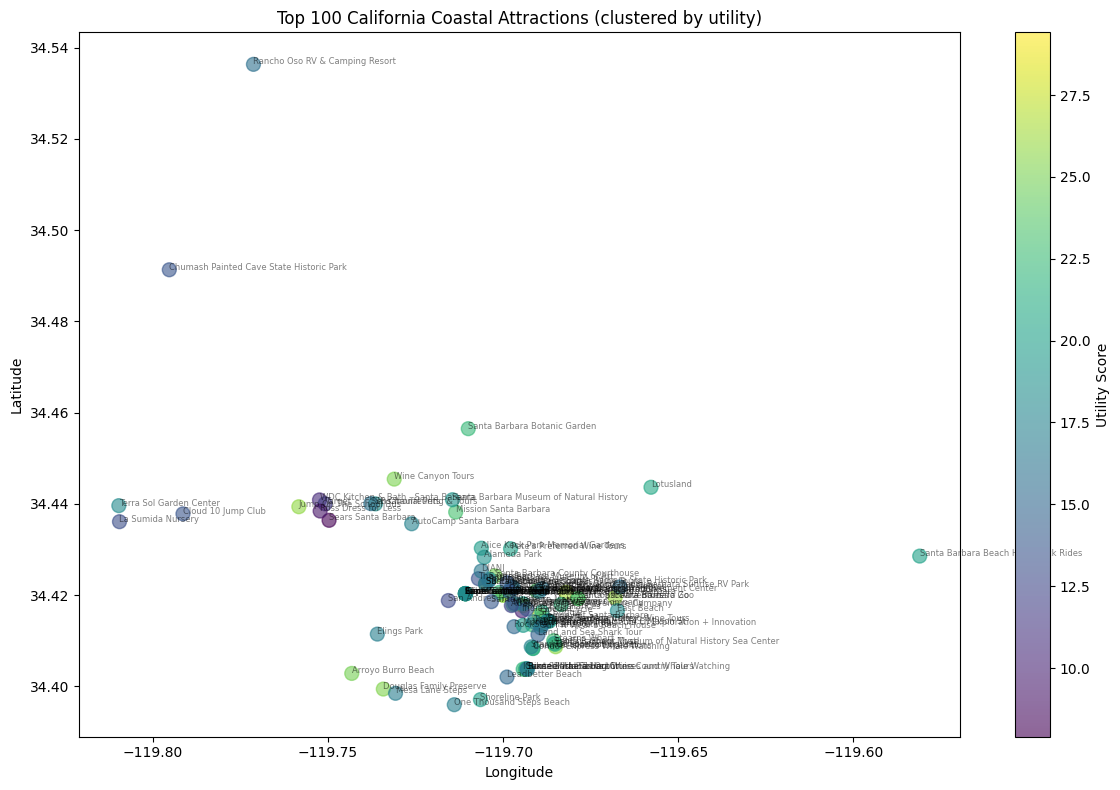

In [79]:
# Step 1: Load Yelp business dataset
# Yelp field names and search semantics are documented in the Yelp Places API docs:
# https://docs.developer.yelp.com/docs/places-intro
# https://docs.developer.yelp.com/reference/v3_business_search
file_path = "Possible Ideas/Travel Plan/Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json"
records = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        records.append({
            "business_id": obj["business_id"],
            "name": obj["name"],
            "city": obj["city"],
            "stars": obj["stars"],
            "review_count": obj["review_count"],
            "latitude": obj["latitude"],
            "longitude": obj["longitude"],
            "categories": obj["categories"]
        })

attractions_df = pd.DataFrame(records)
print(f"✓ Loaded {len(attractions_df)} total businesses")

# Step 2: Filter by California coastal cities
COASTAL_CITIES = ["Santa Barbara", "Santa Cruz", "Monterey", "San Luis Obispo"]
attractions_df = attractions_df[attractions_df["city"].isin(COASTAL_CITIES)]
print(f"✓ Filtered to {len(attractions_df)} attractions in coastal cities")

# Step 3: Filter to tourist attractions only

category_pattern = (
    "Museum|Museums|Park|Parks|Garden|Aquarium|Zoo|"
    "Landmark|Historic|Monument|Observatory|Tour|Attraction|"
    "Beach|Botanical"
)

attractions_df = attractions_df[attractions_df["categories"].notna()]
attractions_df = attractions_df[attractions_df["categories"].str.contains(category_pattern, case=False, regex=True)]
print(f"✓ Filtered to {len(attractions_df)} tourist attractions")

# Step 4: Calculate utility score (rating × review popularity)
attractions_df["utility"] = attractions_df["stars"] * np.log(attractions_df["review_count"] + 1)

# Step 5: Select and plot top 100 attractions
attractions_df = attractions_df.sort_values("review_count", ascending=False)
top100 = attractions_df.head(100)

print("\nTop 100 Attractions Summary:")
print(top100[["name", "stars", "review_count", "utility"]])

# Visualize attraction locations
plt.figure(figsize=(12, 8))
plt.scatter(top100["longitude"], top100["latitude"], c=top100["utility"], cmap="viridis", s=100, alpha=0.6)
plt.colorbar(label="Utility Score")
for _, row in top100.iterrows():
    plt.text(row["longitude"], row["latitude"], row["name"], fontsize=6, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 100 California Coastal Attractions (clustered by utility)")
plt.tight_layout()
plt.show()


## 3. Weather and Hotel Data

In [80]:
############################
# 3.1 GET CITY COORDINATES
############################

CITY = "Santa Barbara"

geo_url = "https://nominatim.openstreetmap.org/search"

geo_params = {
    "q": CITY,
    "format": "json",
    "limit": 1
}

headers = {
    "User-Agent": "IE5533-TravelPlanner/1.0"
}

geo_response = requests.get(geo_url, params=geo_params, headers=headers)

geo_data = geo_response.json()[0]

lat = float(geo_data["lat"])
lon = float(geo_data["lon"])

print("City:", CITY)
print("Latitude:", lat)
print("Longitude:", lon)

City: Santa Barbara
Latitude: 34.4221319
Longitude: -119.702667


### 3.2 Accommodation Dataset from OSM Overpass

In [81]:
############################
# GET HOTELS FROM OSM (with error handling)
############################

import time

radius = 10000

query = f"""
[out:json];
(
  node["tourism"="hotel"](around:{radius},{lat},{lon});
  node["tourism"="guest_house"](around:{radius},{lat},{lon});
  node["tourism"="hostel"](around:{radius},{lat},{lon});
);
out;
"""

url = "https://overpass-api.de/api/interpreter"

# Add retry logic for API robustness
max_retries = 3
retry_count = 0
response = None

while retry_count < max_retries:
    try:
        print(f"Attempting to fetch hotels (attempt {retry_count + 1}/{max_retries})...")
        response = requests.get(url, params={'data': query}, timeout=30)
        
        # Debug: Print status code and content length
        print(f"  Response Status: {response.status_code}")
        print(f"  Response Size: {len(response.text)} bytes")
        
        # Check if response is successful
        if response.status_code != 200:
            print(f"  ✗ HTTP Error: {response.status_code}")
            print(f"  Response: {response.text[:200]}")
            retry_count += 1
            if retry_count < max_retries:
                print(f"  Waiting 5 seconds before retry...")
                time.sleep(5)
            continue
        
        # Try to parse JSON
        data = response.json()
        print(f"  ✓ Successfully fetched hotel data")
        break
        
    except requests.exceptions.Timeout:
        print(f"  ✗ Request timeout")
        retry_count += 1
        if retry_count < max_retries:
            print(f"  Waiting 5 seconds before retry...")
            time.sleep(5)
            
    except requests.exceptions.RequestException as e:
        print(f"  ✗ Request error: {e}")
        retry_count += 1
        if retry_count < max_retries:
            print(f"  Waiting 5 seconds before retry...")
            time.sleep(5)
            
    except ValueError as e:
        print(f"  ✗ JSON Decode Error: {e}")
        if response:
            print(f"  Response text: {response.text[:300]}")
        retry_count += 1
        if retry_count < max_retries:
            print(f"  Waiting 5 seconds before retry...")
            time.sleep(5)

# If API fails, provide fallback
if response is None or retry_count >= max_retries:
    print(f"\n⚠ Warning: Could not fetch hotels from Overpass API after {max_retries} attempts")
    print("Using hardcoded fallback hotel data for Santa Barbara...\n")
    
    # Fallback: Manual hotel entries for Santa Barbara
    data = {
        "elements": [
            {
                "lat": 34.4208,
                "lon": -119.6982,
                "tags": {"name": "Harbor View Inn", "tourism": "hotel", "stars": "4"}
            },
            {
                "lat": 34.4260,
                "lon": -119.6940,
                "tags": {"name": "Santa Barbara Inn", "tourism": "hotel", "stars": "4"}
            },
            {
                "lat": 34.4380,
                "lon": -119.6850,
                "tags": {"name": "Simpson House Inn", "tourism": "guest_house", "stars": "4"}
            },
            {
                "lat": 34.4100,
                "lon": -119.7050,
                "tags": {"name": "Hostel Santa Barbara", "tourism": "hostel", "stars": "3"}
            }
        ]
    }

hotels = []

for e in data["elements"]:
    tags = e.get("tags", {})
    hotels.append({
        "name": tags.get("name", "unknown"),
        "latitude": e["lat"],
        "longitude": e["lon"],
        "stars": tags.get("stars"),
        "type": tags.get("tourism")
    })

hotels_df = pd.DataFrame(hotels)

print(f"Hotels found: {len(hotels_df)}")
print("\nHotel List:")
print(hotels_df[["name", "type", "stars"]])


Attempting to fetch hotels (attempt 1/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:
  Waiting 5 seconds before retry...
Attempting to fetch hotels (attempt 2/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:
  Waiting 5 seconds before retry...
Attempting to fetch hotels (attempt 3/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.d

In [82]:
# Section 3.1: Retrieve city coordinates and weather archive data

import time

CITY = "Santa Barbara"

# Get city coordinates using Nominatim
geo_url = "https://nominatim.openstreetmap.org/search"
geo_params = {"q": CITY, "format": "json", "limit": 1}
headers = {"User-Agent": "IE5533-TravelPlanner/1.0"}

geo_response = requests.get(geo_url, params=geo_params, headers=headers)
geo_data = geo_response.json()[0]
lat, lon = float(geo_data["lat"]), float(geo_data["lon"])
print(f"City: {CITY} | Coordinates: ({lat:.4f}, {lon:.4f})")

# Section 3.2: Fetch accommodation dataset from OpenStreetMap (Overpass) with retry logic
# API citation: https://wiki.openstreetmap.org/wiki/Overpass_API
# This step builds the candidate overnight set H used in the hotel-selection extension.
radius = 10000
query = f"""
[out:json];
(
  node["tourism"~"hotel|guest_house|hostel|motel|apartment"](around:{radius},{lat},{lon});
  way["tourism"~"hotel|guest_house|hostel|motel|apartment"](around:{radius},{lat},{lon});
  relation["tourism"~"hotel|guest_house|hostel|motel|apartment"](around:{radius},{lat},{lon});
);
out center;
"""

url = "https://overpass-api.de/api/interpreter"

# Retry logic for API robustness
max_retries = 3
retry_count = 0
response = None
data = None

while retry_count < max_retries:
    try:
        print(f"  Fetching hotels (attempt {retry_count + 1}/{max_retries})...")
        response = requests.get(url, params={'data': query}, timeout=30)
        
        if response.status_code != 200:
            print(f"    ✗ HTTP {response.status_code}")
            retry_count += 1
            if retry_count < max_retries:
                time.sleep(5)
            continue
        
        data = response.json()
        print(f"  ✓ Accommodations fetched successfully")
        break
        
    except (requests.exceptions.Timeout, requests.exceptions.RequestException, ValueError) as e:
        print(f"    ✗ Error: {type(e).__name__}")
        retry_count += 1
        if retry_count < max_retries:
            time.sleep(5)

# Fallback if API fails
if data is None:
    print(f"  ⚠ Using fallback accommodation data for Santa Barbara\n")
    data = {
        "elements": [
            {"lat": 34.4208, "lon": -119.6982, "tags": {"name": "Harbor View Inn", "tourism": "hotel", "stars": "4"}},
            {"lat": 34.4260, "lon": -119.6940, "tags": {"name": "Santa Barbara Inn", "tourism": "hotel", "stars": "4"}},
            {"lat": 34.4380, "lon": -119.6850, "tags": {"name": "Simpson House Inn", "tourism": "guest_house", "stars": "4"}},
            {"lat": 34.4100, "lon": -119.7050, "tags": {"name": "Hostel Santa Barbara", "tourism": "hostel", "stars": "3"}},
            {"lat": 34.4285, "lon": -119.7170, "tags": {"name": "Sunset Motel", "tourism": "motel", "stars": "2"}},
            {"lat": 34.4165, "lon": -119.6922, "tags": {"name": "Downtown Garden Suites", "tourism": "apartment", "stars": "4"}}
        ]
    }

hotels = []
for e in data["elements"]:
    tags = e.get("tags", {})
    element_lat = e.get("lat", e.get("center", {}).get("lat"))
    element_lon = e.get("lon", e.get("center", {}).get("lon"))
    if element_lat is None or element_lon is None:
        continue
    hotels.append({
        "name": tags.get("name", "unknown"),
        "latitude": element_lat,
        "longitude": element_lon,
        "stars": tags.get("stars"),
        "type": tags.get("tourism")
    })

hotels_df = pd.DataFrame(hotels)
print(f"✓ Found {len(hotels_df)} hotels/accommodations")

# Section 3.3: Retrieve historical weather data
weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2001-01-01",
    "end_date": "2026-03-23",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "auto"
}

weather_response = requests.get(weather_url, params=weather_params)
weather_json = weather_response.json()

weather_df = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temp_max": weather_json["daily"]["temperature_2m_max"],
    "temp_min": weather_json["daily"]["temperature_2m_min"],
    "precipitation": weather_json["daily"]["precipitation_sum"]
})

weather_df["date"] = pd.to_datetime(weather_df["date"]).dt.date
print(f"✓ Loaded {len(weather_df)} days of historical weather")

# Section 3.4: Engineer weather features
weather_df["avg_temp"] = (weather_df["temp_max"] + weather_df["temp_min"]) / 2
weather_df["RainFlag"] = (weather_df["precipitation"] > 0).astype(int)
weather_df["ColdFlag"] = (weather_df["avg_temp"] < 5).astype(int)
weather_df["day_of_week"] = pd.to_datetime(weather_df["date"]).dt.dayofweek
weather_df["Weekend"] = (weather_df["day_of_week"] >= 5).astype(int)

weather_df.to_csv("santa_barbara_weather.csv", index=False)
print("✓ Weather features engineered and saved")

# Create cross-join of weather with attractions
weather_df["key"] = 1
attractions_df["key"] = 1
attraction_weather = weather_df.merge(attractions_df, on="key").drop("key", axis=1)
attraction_weather["day_of_week"] = pd.to_datetime(attraction_weather["date"]).dt.dayofweek
attraction_weather["weekend"] = (attraction_weather["day_of_week"] >= 5).astype(int)
attraction_weather.to_csv("attraction_weather_dataset.csv", index=False)
print("✓ Attraction-weather dataset created and saved\n")


City: Santa Barbara | Coordinates: (34.4221, -119.7027)
  Fetching hotels (attempt 1/3)...
  ✓ Accommodations fetched successfully
✓ Found 76 hotels/accommodations
✓ Loaded 9213 days of historical weather
✓ Weather features engineered and saved
✓ Attraction-weather dataset created and saved



### 3.3 Accommodation Enrichment

In [83]:
# Section 3.3: Enrich accommodations with price and quality proxies using OSM + Yelp.
# API citations:
# - Yelp Places API intro: https://docs.developer.yelp.com/docs/places-intro
# - Yelp business search: https://docs.developer.yelp.com/reference/v3_business_search
# Academic motivation: OPHS-style models benefit from heterogeneous overnight nodes [3, 4].
# Since we do not have a free booking API here, Yelp rating and price tier are treated as
# accommodation quality and cost proxies instead of literal bookable nightly rates.

from difflib import SequenceMatcher
from pathlib import Path
import os
import re

# Local Yelp configuration for this notebook run.
# The Base plan screenshot shows a limited quota, so we keep a cache and a per-run live-call cap.
# Remove or externalize these credentials before sharing the notebook publicly.
YELP_CLIENT_ID = os.getenv("YELP_CLIENT_ID") or "NWB370iYCunb5uN1aOPUBA"
YELP_API_KEY = os.getenv("YELP_API_KEY") or os.getenv("YELP_API_TOKEN") or "-q-btvH1M8Rwh5S82NMWsGAH0LH0FRjVZn-IJpBW6UOwDyu2-lvXtLJhgajfIuqvHx4RJ1108FsFhEo8SwJ7t8AxGZ5nwJbMAcjgw2RWNDUNo38qBXPfE1X5yzLgaXYx"
YELP_API_TOKEN = YELP_API_KEY
YELP_ACCOMMODATION_QUERY_LIMIT = int(os.getenv("YELP_ACCOMMODATION_QUERY_LIMIT", "80"))
YELP_ACCOMMODATION_CACHE_PATH = Path(os.getenv("YELP_ACCOMMODATION_CACHE_PATH", "results/yelp_accommodation_cache.json"))
YELP_ACCOMMODATION_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

hotels_df = hotels_df.copy()
hotels_df["name"] = hotels_df["name"].fillna("unknown")
hotels_df["stars"] = pd.to_numeric(hotels_df["stars"], errors="coerce")
hotels_df["type"] = hotels_df["type"].fillna("hotel").str.lower()
hotels_df["lodging_type"] = hotels_df["type"].replace({"apartment": "airbnb"})
hotels_df = hotels_df.drop_duplicates(subset=["name", "latitude", "longitude", "lodging_type"]).reset_index(drop=True)

TYPE_PRICE_DEFAULTS = {
    "hotel": 145.0,
    "hostel": 55.0,
    "guest_house": 125.0,
    "motel": 85.0,
    "airbnb": 135.0,
}
TYPE_RATING_DEFAULTS = {
    "hotel": 4.1,
    "hostel": 3.5,
    "guest_house": 4.3,
    "motel": 3.2,
    "airbnb": 4.2,
}
TYPE_EXPERIENCE_DEFAULTS = {
    "hotel": 4.0,
    "hostel": 3.3,
    "guest_house": 4.2,
    "motel": 3.0,
    "airbnb": 4.1,
}
PRICE_TIER_TO_PROXY = {
    "$": 85.0,
    "$$": 140.0,
    "$$$": 220.0,
    "$$$$": 320.0,
}

def normalize_name(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()

def estimate_price_from_type(row):
    base_price = TYPE_PRICE_DEFAULTS.get(row["lodging_type"], TYPE_PRICE_DEFAULTS["hotel"])
    stars = row["stars"] if pd.notna(row["stars"]) else TYPE_RATING_DEFAULTS.get(row["lodging_type"], 4.0)
    return round(base_price + 10.0 * max(stars - 3.0, 0), 2)

def review_strength(review_count):
    return min(np.log1p(review_count) / np.log1p(500), 1.0)

def yelp_price_to_proxy(price_tier, lodging_type):
    if price_tier in PRICE_TIER_TO_PROXY:
        return PRICE_TIER_TO_PROXY[price_tier]
    return TYPE_PRICE_DEFAULTS.get(lodging_type, TYPE_PRICE_DEFAULTS["hotel"])

def build_experience_score(rating_score, review_count, lodging_type):
    if pd.isna(rating_score):
        return TYPE_EXPERIENCE_DEFAULTS.get(lodging_type, 4.0)
    confidence_component = 1.0 + 4.0 * review_strength(review_count)
    return round(0.7 * float(rating_score) + 0.3 * confidence_component, 2)

def yelp_cache_key(osm_row, radius_m=2500, limit=10):
    search_term = osm_row["name"] if osm_row["name"] != "unknown" else osm_row["lodging_type"].replace("_", " ")
    return "|".join([
        normalize_name(search_term),
        f"{float(osm_row['latitude']):.4f}",
        f"{float(osm_row['longitude']):.4f}",
        str(radius_m),
        str(limit),
    ])

def yelp_search_candidates(api_key, osm_row, radius_m=2500, limit=10, cache=None):
    cache_key = yelp_cache_key(osm_row, radius_m=radius_m, limit=limit)
    if cache is not None and cache_key in cache:
        return cache[cache_key], True
    headers = {"Authorization": f"Bearer {api_key}"}
    search_term = osm_row["name"] if osm_row["name"] != "unknown" else osm_row["lodging_type"].replace("_", " ")
    params = {
        "term": search_term,
        "latitude": float(osm_row["latitude"]),
        "longitude": float(osm_row["longitude"]),
        "radius": min(radius_m, 40000),
        "limit": limit,
        "sort_by": "best_match",
    }
    response = requests.get(
        "https://api.yelp.com/v3/businesses/search",
        headers=headers,
        params=params,
        timeout=30,
    )
    response.raise_for_status()
    businesses = response.json().get("businesses", [])
    if cache is not None:
        cache[cache_key] = businesses
    return businesses, False

def build_yelp_candidate_frame(candidates):
    rows = []
    for business in candidates:
        coords = business.get("coordinates") or {}
        rows.append({
            "yelp_business_id": business.get("id"),
            "yelp_name": business.get("name"),
            "yelp_name_norm": normalize_name(business.get("name", "")),
            "latitude": coords.get("latitude"),
            "longitude": coords.get("longitude"),
            "rating": business.get("rating"),
            "review_count": business.get("review_count", 0),
            "price_tier": business.get("price"),
        })
    return pd.DataFrame(rows).dropna(subset=["latitude", "longitude"])

def match_accommodation(osm_row, yelp_df):
    if yelp_df.empty:
        return None
    osm_coords = (osm_row["latitude"], osm_row["longitude"])
    osm_name_norm = normalize_name(osm_row["name"])
    candidates = yelp_df.copy()
    candidates["distance_km"] = candidates.apply(
        lambda row: geodesic(osm_coords, (row["latitude"], row["longitude"])).km,
        axis=1,
    )
    if osm_row["name"] == "unknown":
        candidates["name_similarity"] = 0.5
    else:
        candidates["name_similarity"] = candidates["yelp_name_norm"].apply(
            lambda name: SequenceMatcher(None, osm_name_norm, name).ratio()
        )
    candidates["review_strength"] = candidates["review_count"].apply(review_strength)
    candidates = candidates[(candidates["distance_km"] <= 3.0) | (candidates["name_similarity"] >= 0.72)]
    if candidates.empty and osm_row["name"] == "unknown":
        nearest_idx = yelp_df.apply(
            lambda row: geodesic(osm_coords, (row["latitude"], row["longitude"])).km,
            axis=1,
        ).idxmin()
        candidate = yelp_df.loc[nearest_idx]
        if geodesic(osm_coords, (candidate["latitude"], candidate["longitude"])).km <= 1.0:
            return candidate
        return None
    if candidates.empty:
        return None
    candidates["match_score"] = (
        candidates["name_similarity"]
        + 0.04 * candidates["review_strength"]
        + 0.02 * candidates["rating"].fillna(0) / 5.0
        - 0.08 * candidates["distance_km"]
    )
    return candidates.sort_values(["match_score", "review_count"], ascending=[False, False]).iloc[0]

hotels_df["name_norm"] = hotels_df["name"].apply(normalize_name)
hotels_df["yelp_business_id"] = None
hotels_df["yelp_distance_km"] = np.nan
hotels_df["price_tier"] = None
hotels_df["review_count"] = 0
hotels_df["price_currency"] = "USD_proxy"
hotels_df["nightly_price"] = hotels_df.apply(estimate_price_from_type, axis=1)
hotels_df["price_source"] = "estimated_from_type"
hotels_df["price_estimated"] = True
hotels_df["rating_score"] = hotels_df["stars"].fillna(hotels_df["lodging_type"].map(TYPE_RATING_DEFAULTS)).astype(float)
hotels_df["experience_score"] = hotels_df.apply(
    lambda row: build_experience_score(row["rating_score"], 0, row["lodging_type"]),
    axis=1,
)

yelp_api_key = YELP_API_KEY
match_count = 0
cache_hits = 0
live_api_calls = 0
cache_updated = False
if YELP_ACCOMMODATION_CACHE_PATH.exists():
    with YELP_ACCOMMODATION_CACHE_PATH.open("r", encoding="utf-8") as f:
        yelp_cache = json.load(f)
else:
    yelp_cache = {}

if not yelp_api_key:
    print("ℹ Yelp API key not found. Using OSM accommodations plus estimated defaults.")
else:
    print(f"Querying Yelp Places API to enrich accommodation quality and price tiers (live-call cap: {YELP_ACCOMMODATION_QUERY_LIMIT})...")
    live_limit_reached = False
    for idx, row in hotels_df.iterrows():
        cache_key = yelp_cache_key(row)
        if cache_key not in yelp_cache and live_api_calls >= YELP_ACCOMMODATION_QUERY_LIMIT:
            if not live_limit_reached:
                print("ℹ Reached the live Yelp-call cap for this run. Remaining accommodations will keep their estimated defaults.")
                live_limit_reached = True
            continue
        try:
            candidates, from_cache = yelp_search_candidates(yelp_api_key, row, cache=yelp_cache)
            if from_cache:
                cache_hits += 1
            else:
                live_api_calls += 1
                cache_updated = True
            yelp_df = build_yelp_candidate_frame(candidates)
            match = match_accommodation(row, yelp_df)
        except requests.exceptions.HTTPError as exc:
            status_code = exc.response.status_code if exc.response is not None else "unknown"
            print(f"⚠ Yelp enrichment stopped for {row['name']}: HTTP {status_code}")
            if status_code in {401, 403, 429}:
                break
            continue
        except Exception as exc:
            print(f"⚠ Yelp enrichment skipped for {row['name']}: {type(exc).__name__}")
            continue
        if match is None:
            continue
        match_count += 1
        hotels_df.at[idx, "yelp_business_id"] = match["yelp_business_id"]
        hotels_df.at[idx, "yelp_distance_km"] = round(float(match.get("distance_km", np.nan)), 3)
        hotels_df.at[idx, "review_count"] = int(match.get("review_count", 0))
        hotels_df.at[idx, "price_tier"] = match.get("price_tier")
        hotels_df.at[idx, "rating_score"] = float(match.get("rating", hotels_df.at[idx, "rating_score"]))
        hotels_df.at[idx, "nightly_price"] = yelp_price_to_proxy(match.get("price_tier"), row["lodging_type"])
        hotels_df.at[idx, "price_source"] = "yelp_price_tier" if match.get("price_tier") else "type_estimate_after_yelp_match"
        hotels_df.at[idx, "price_estimated"] = match.get("price_tier") is None
        hotels_df.at[idx, "experience_score"] = build_experience_score(
            hotels_df.at[idx, "rating_score"],
            hotels_df.at[idx, "review_count"],
            row["lodging_type"],
        )

if cache_updated:
    with YELP_ACCOMMODATION_CACHE_PATH.open("w", encoding="utf-8") as f:
        json.dump(yelp_cache, f, indent=2)

hotels_df["cost_proxy_note"] = "Yelp price tier when available; otherwise type-based accommodation cost proxy"
hotels_df["value_score"] = (hotels_df["rating_score"] * hotels_df["experience_score"]) / hotels_df["nightly_price"].clip(lower=1)
hotels_df = hotels_df.sort_values(["nightly_price", "rating_score"], ascending=[True, False]).reset_index(drop=True)
hotels_df.to_csv("hotel_dataset_enriched.csv", index=False)

print(f"✓ Accommodation records after cleaning: {len(hotels_df)}")
print(f"✓ Yelp-enriched matches: {match_count}")
print(f"✓ Yelp cache hits this run: {cache_hits}")
print(f"✓ Live Yelp API calls used this run: {live_api_calls}")
print(f"✓ Yelp cache file: {YELP_ACCOMMODATION_CACHE_PATH}")
print(hotels_df[["name", "lodging_type", "price_tier", "nightly_price", "rating_score", "experience_score", "price_source"]].head(10))

Querying Yelp Places API to enrich accommodation quality and price tiers (live-call cap: 80)...
⚠ Yelp enrichment skipped for IHSP Santa Barbara: KeyError
⚠ Yelp enrichment skipped for Autocamp Santa Barbara: KeyError
✓ Accommodation records after cleaning: 76
✓ Yelp-enriched matches: 74
✓ Yelp cache hits this run: 76
✓ Live Yelp API calls used this run: 0
✓ Yelp cache file: results/yelp_accommodation_cache.json
                     name lodging_type price_tier  nightly_price  \
0            Social Stays       hostel       None           55.0   
1      IHSP Santa Barbara       hostel       None           60.0   
2             Haley Hotel        motel       None           85.0   
3    Town and Country Inn        motel          $           85.0   
4  Autocamp Santa Barbara        motel       None           87.0   
5        Cheshire Cat Inn  guest_house       None          125.0   
6        Harbor House Inn        motel         $$          140.0   
7         Beach House Inn        motel  

## 4. Travel Distance Matrix

In [84]:
# Section 4.1: Compute pairwise travel distances between attractions

locations = top100[["name", "latitude", "longitude"]].reset_index(drop=True)
n = len(locations)

# Calculate geodesic distances
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        coord_i = (locations.loc[i, "latitude"], locations.loc[i, "longitude"])
        coord_j = (locations.loc[j, "latitude"], locations.loc[j, "longitude"])
        distance = geodesic(coord_i, coord_j).km
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

# Convert distances to travel time (assuming avg 20 km/h)
avg_speed = 20  # km/h
travel_time_matrix = distance_matrix / avg_speed * 60

travel_time_df = pd.DataFrame(
    travel_time_matrix,
    index=locations["name"],
    columns=locations["name"]
)
travel_time_df.to_csv("travel_time_matrix.csv")
print("✓ Travel time matrix computed (20 km/h assumed)")
print(travel_time_df.head())

# Section 4.2: Compute hotel-to-attraction travel times

hotel_locations = hotels_df[["latitude", "longitude"]].values
attraction_locations = top100[["latitude", "longitude"]].values

num_hotels = len(hotel_locations)
num_attr = len(attraction_locations)

hotel_to_attr = np.zeros((num_hotels, num_attr))
for h in range(num_hotels):
    for i in range(num_attr):
        coord_h = tuple(hotel_locations[h])
        coord_i = tuple(attraction_locations[i])
        dist = geodesic(coord_h, coord_i).km
        hotel_to_attr[h, i] = dist

hotel_to_attr_time = hotel_to_attr / avg_speed * 60
print(f"✓ Hotel-to-attraction matrix: {hotel_to_attr_time.shape}")

# Section 4.3: Compute hotel-to-hotel travel times for stay/switch decisions
hotel_to_hotel = np.zeros((num_hotels, num_hotels))
for h in range(num_hotels):
    for g in range(num_hotels):
        coord_h = tuple(hotel_locations[h])
        coord_g = tuple(hotel_locations[g])
        hotel_to_hotel[h, g] = geodesic(coord_h, coord_g).km

hotel_to_hotel_time = hotel_to_hotel / avg_speed * 60
pd.DataFrame(hotel_to_hotel_time, index=hotels_df["name"], columns=hotels_df["name"]).to_csv("hotel_to_hotel_time.csv")
print(f"✓ Hotel-to-hotel matrix: {hotel_to_hotel_time.shape}")

# Save datasets
hotels_df.to_csv("hotel_dataset.csv", index=False)
print("✓ Hotel and travel matrices saved\n")


✓ Travel time matrix computed (20 km/h assumed)
name                           Santa Barbara Zoo  Sustainable Wine Tours  \
name                                                                       
Santa Barbara Zoo                       0.000000               10.257437   
Sustainable Wine Tours                 10.257437                0.000000   
Mission Santa Barbara                  14.023406                5.745116   
Captain Jack's Tours & Events          11.792684                1.729896   
Stearns Wharf                           5.773017                6.780379   

name                           Mission Santa Barbara  \
name                                                   
Santa Barbara Zoo                          14.023406   
Sustainable Wine Tours                      5.745116   
Mission Santa Barbara                       0.000000   
Captain Jack's Tours & Events               5.996123   
Stearns Wharf                              12.150771   

name                      

### 4.2 Hotel-to-Attraction Travel Time

In [85]:
############################
# HOTEL → ATTRACTION DISTANCE
############################

hotel_locations = hotels_df[["latitude","longitude"]].values
attraction_locations = top100[["latitude","longitude"]].values

num_hotels = len(hotel_locations)
num_attr = len(attraction_locations)

hotel_to_attr = np.zeros((num_hotels, num_attr))

for h in range(num_hotels):

    for i in range(num_attr):

        coord_h = tuple(hotel_locations[h])
        coord_i = tuple(attraction_locations[i])

        dist = geodesic(coord_h, coord_i).km

        hotel_to_attr[h,i] = dist

# convert to minutes
hotel_to_attr_time = hotel_to_attr / avg_speed * 60

print("Hotel→Attraction matrix:", hotel_to_attr_time.shape)

Hotel→Attraction matrix: (76, 100)


## 5. Review Density and Waiting Time

In [86]:
# Section 5.1: Load and process Yelp review dataset to estimate review density

file_path = "Possible Ideas/Travel Plan/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json"
reviews = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        reviews.append({
            "business_id": obj["business_id"],
            "date": obj["date"],
            "stars": obj["stars"]
        })

review_df = pd.DataFrame(reviews)
review_df["date"] = pd.to_datetime(review_df["date"]).dt.date

# Filter to selected attractions
selected_ids = top100["business_id"].tolist()
review_df = review_df[review_df["business_id"].isin(selected_ids)]

# Aggregate review counts by business and date
review_density = (
    review_df
    .groupby(["business_id", "date"])
    .size()
    .reset_index(name="review_count")
)

print(f"✓ Processed {len(review_df)} reviews")
print(f"✓ Review density aggregated (shape: {review_density.shape})")
print(review_density.head())


✓ Processed 10808 reviews
✓ Review density aggregated (shape: (10277, 3))
              business_id        date  review_count
0  --O3ip9NpXTKD4oBS1pY2A  2007-08-14             1
1  --O3ip9NpXTKD4oBS1pY2A  2007-10-23             1
2  --O3ip9NpXTKD4oBS1pY2A  2007-11-20             1
3  --O3ip9NpXTKD4oBS1pY2A  2008-06-05             1
4  --O3ip9NpXTKD4oBS1pY2A  2009-06-18             1


## 6. Attraction Duration Estimation

In [87]:
# Section 6.1: Define duration estimates for each attraction type

DURATION_MAP = {
    "Zoo": (90, 120, 180),
    "Museum": (60, 90, 120),
    "Aquarium": (90, 120, 150),
    "Botanical": (60, 90, 120),
    "Garden": (60, 90, 120),
    "Park": (60, 90, 120),
    "Beach": (60, 90, 120),
    "Historic": (45, 60, 90),
    "Landmark": (45, 60, 75),
    "Monument": (45, 60, 75),
    "Observatory": (60, 90, 120),
    "Tour": (100, 120, 180),
    "Attraction": (60, 90, 120)
}

# Helper functions for PERT distribution
def pert_mean(a, m, b):
    """Calculate mean of PERT (optimistic, mode, pessimistic)."""
    return (a + 4*m + b) / 6

def pert_sd(a, b):
    """Calculate standard deviation of PERT."""
    return (b - a) / 6

def estimate_duration(category_string):
    """Estimate visit duration from attraction category."""
    for key in DURATION_MAP:
        if key.lower() in category_string.lower():
            a, m, b = DURATION_MAP[key]
            return pert_mean(a, m, b)
    return 60

def estimate_sigma(category_string):
    """Estimate variation in visit duration."""
    for key in DURATION_MAP:
        if key.lower() in category_string.lower():
            a, _, b = DURATION_MAP[key]
            return pert_sd(a, b)
    return 15

# Section 6.2: Apply duration estimation to top attractions

attractions_df["estimated_duration"] = attractions_df["categories"].apply(estimate_duration)
top100["estimated_duration"] = top100["categories"].apply(estimate_duration)

top100["sigma"] = top100["categories"].apply(estimate_sigma)

# Simulate visit durations with Gaussian noise
top100["visit_duration_sim"] = np.random.normal(
    top100["estimated_duration"],
    top100["sigma"]
)

print("✓ Visit duration simulation complete")
print(top100[["name", "categories", "estimated_duration", "sigma", "visit_duration_sim"]].head())

# Save to CSV
pd.DataFrame({
    "name": top100["name"],
    "categories": top100["categories"],
    "estimated_duration": top100["estimated_duration"],
    "sigma": top100["sigma"],
    "visit_duration_sim": top100["visit_duration_sim"]
}).to_csv("attraction_durations.csv", index=False)


✓ Visit duration simulation complete
                                 name  \
118248              Santa Barbara Zoo   
130633         Sustainable Wine Tours   
23727           Mission Santa Barbara   
142336  Captain Jack's Tours & Events   
40345                   Stearns Wharf   

                                               categories  estimated_duration  \
118248  Zoos, Event Planning & Services, Venues & Even...          125.000000   
130633  Wine Tours, Hotels & Travel, Tours, Transporta...          126.666667   
23727   Churches, Arts & Entertainment, Museums, Relig...           90.000000   
142336  Active Life, Wineries, Tours, Horseback Riding...          126.666667   
40345   Public Services & Government, Landmarks & Hist...           62.500000   

            sigma  visit_duration_sim  
118248  15.000000          141.346125  
130633  13.333333          107.283050  
23727   10.000000           90.040732  
142336  13.333333          147.076293  
40345    7.500000           7

/var/folders/yz/6cz7g4dj7438_n6z0rlsmnb00000gn/T/ipykernel_4308/947970106.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["estimated_duration"] = top100["categories"].apply(estimate_duration)
/var/folders/yz/6cz7g4dj7438_n6z0rlsmnb00000gn/T/ipykernel_4308/947970106.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["sigma"] = top100["categories"].apply(estimate_sigma)
/var/folders/yz/6cz7g4dj7438_n6z0rlsmnb00000gn/T/ipykernel_4308/947970106.py:52: SettingWithCopyWarning: 
A value is try

## 7. Waiting Time Modeling with XGBoost

In [88]:
!pip3.12 install xgboost

In [89]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Model Performance: RMSE = 0.280, MSE = 0.078


/var/folders/yz/6cz7g4dj7438_n6z0rlsmnb00000gn/T/ipykernel_4308/95407687.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["type"] = top100["name"].apply(classify_attraction)


✓ Waiting time model trained and applied
                            name     type  waiting_time
0              Santa Barbara Zoo      zoo     11.035337
1         Sustainable Wine Tours     tour     41.906687
2          Mission Santa Barbara  general     13.456183
3  Captain Jack's Tours & Events     tour     42.772789
4                  Stearns Wharf  general     13.642194


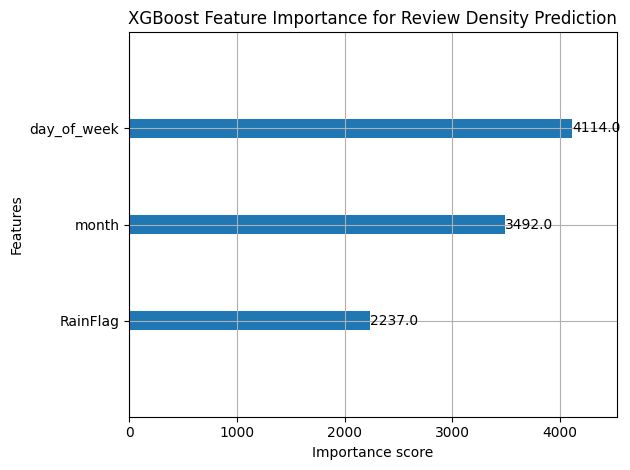

In [90]:
# Section 7.1: Prepare features for waiting time prediction model

# Merge review density with weather and feature engineering
review_weather_density = review_density.merge(
    weather_df[["date", "RainFlag", "ColdFlag"]],
    on="date",
    how="left"
)

review_weather_density["day_of_week"] = pd.to_datetime(review_weather_density["date"]).dt.dayofweek
review_weather_density["month"] = pd.to_datetime(review_weather_density["date"]).dt.month
review_weather_density["weekend"] = (review_weather_density["day_of_week"] >= 5).astype(int)

# Section 7.2: Train XGBoost model to predict review density

X = review_weather_density[["day_of_week", "month", "weekend", "RainFlag"]]
y = review_weather_density["review_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Model Performance: RMSE = {rmse:.3f}, MSE = {mse:.3f}")

# Section 7.3: Predict visitor density and classify attractions

review_weather_density["predicted_review_count"] = model.predict(X)

# Convert reviews to estimated visitor count (tourism research: 0.078% participation rate)
PARTICIPATION_RATE = 0.00078
review_weather_density["estimated_visitors"] = (
    review_weather_density["predicted_review_count"] / PARTICIPATION_RATE
)

# Section 7.4: Classify attractions by type

def classify_attraction(name):
    name_lower = name.lower()
    if "beach" in name_lower:
        return "beach"
    elif "park" in name_lower:
        return "park"
    elif "museum" in name_lower:
        return "museum"
    elif "zoo" in name_lower:
        return "zoo"
    elif any(x in name_lower for x in ["wine", "whale", "tour"]):
        return "tour"
    elif "adventure" in name_lower:
        return "activity"
    else:
        return "general"

top100["type"] = top100["name"].apply(classify_attraction)
review_weather_density = review_weather_density.merge(
    top100[["business_id", "type"]],
    on="business_id",
    how="left"
)

# Section 7.5: Model waiting times based on capacity and visitor load

CAPACITY_TABLE = {
    "beach": 5000, "park": 3000, "museum": 800,
    "zoo": 700, "tour": 200, "activity": 150, "general": 500
}

BASE_WAIT_TABLE = {
    "beach": 2, "park": 3, "museum": 8,
    "zoo": 10, "tour": 20, "activity": 25, "general": 10
}

def compute_waiting(row):
    visitors = row["estimated_visitors"]
    attraction_type = row["type"]
    capacity = CAPACITY_TABLE.get(attraction_type, 500)
    base_wait = BASE_WAIT_TABLE.get(attraction_type, 10)
    wait = base_wait * np.log1p(visitors / capacity)
    noise = np.random.lognormal(mean=0, sigma=0.25)
    return wait * noise

review_weather_density["waiting_time"] = review_weather_density.apply(compute_waiting, axis=1)
review_weather_density["waiting_time"] = review_weather_density["waiting_time"].clip(1, 120)

# Section 7.6: Aggregate waiting times per attraction

waiting_time_avg = (
    review_weather_density
    .groupby("business_id")["waiting_time"]
    .mean()
    .reset_index()
)

top100_with_waiting_time = top100.merge(
    waiting_time_avg,
    on="business_id",
    how="left"
)

print(f"✓ Waiting time model trained and applied")
print(top100_with_waiting_time[["name", "type", "waiting_time"]].head())

# Visualize feature importance
xgb.plot_importance(model)
plt.title("XGBoost Feature Importance for Review Density Prediction")
plt.tight_layout()
plt.show()


## 8. Route Optimization

### Literature-Based Formulation Note

This optimization section follows the TTDP literature [1, 2] and extends it with hotel-selection ideas from OPHS [3, 4]. In our notebook, attraction nodes carry utility, waiting-time, and visit-duration information, while accommodation nodes represent overnight choices. The multi-day extension therefore optimizes three linked decisions at once:

- attraction selection and sequencing,
- daily hotel choice,
- whether to stay in the same hotel or switch hotels between days.

The resulting model is not a pure classical orienteering problem. It is closer to a practical TTDP/OPHS hybrid in which weather, congestion, attraction utility, accommodation cost proxies, hotel quality, and relocation effort all affect the objective. The overnight switching term is modeled as a penalty in the objective rather than as daytime sightseeing time, because hotel relocation is treated as an overnight decision in this project.

In [91]:
!pip3.12 install ortools

In [92]:
from ortools.linear_solver import pywraplp

n = len(top100_with_waiting_time)

In [93]:
########################################
# SECTION 8.1: REAL-TIME WEATHER → WAITING PREDICTION
########################################

import requests
from datetime import datetime

lat = top100_with_waiting_time["latitude"].mean()
lon = top100_with_waiting_time["longitude"].mean()

weather_url = "https://api.open-meteo.com/v1/forecast"

weather_params = {
    "latitude": lat,
    "longitude": lon,
    "current_weather": True,
    "hourly": "precipitation_probability",
    "forecast_days": 1
}

response = requests.get(weather_url, params=weather_params)
weather_now = response.json()

# Build real-time feature vector
now = datetime.now()

day_of_week = now.weekday()
month = now.month
weekend = int(day_of_week >= 5)

RainFlag = int(weather_now["hourly"]["precipitation_probability"][0] > 50)

X_live = pd.DataFrame({
    "day_of_week":[day_of_week],
    "month":[month],
    "weekend":[weekend],
    "RainFlag":[RainFlag]
})

# Predict review density using trained XGBoost model
pred_review_density = model.predict(X_live)[0]

# Convert review density → visitors
PARTICIPATION_RATE = 0.00078
estimated_visitors_live = pred_review_density / PARTICIPATION_RATE

print(f"Real-time forecast for {now.strftime('%Y-%m-%d %H:%M')}")
print(f"  Day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][day_of_week]} | Month: {month} | Weekend: {weekend}")
print(f"  Rain probability: {weather_now['hourly']['precipitation_probability'][0]:.1f}%")
print(f"  Predicted review density: {pred_review_density:.1f}")
print(f"  Estimated live visitors: {estimated_visitors_live:.1f}\n")

########################################
# SECTION 8.2: REAL-TIME WAITING TIME (BLENDED)
########################################

# Use CAPACITY_TABLE and BASE_WAIT_TABLE from XGBoost section (7.5)
live_waiting = []

for t in top100_with_waiting_time["type"]:
    capacity = CAPACITY_TABLE.get(t, 500)
    base_wait = BASE_WAIT_TABLE.get(t, 10)
    wait = base_wait * np.log1p(estimated_visitors_live / capacity)
    live_waiting.append(wait)

top100_with_waiting_time["waiting_time_live"] = live_waiting

# Blend historical and live waiting times (70% historical, 30% live forecast)
top100_with_waiting_time["waiting_final"] = (
    0.7 * top100_with_waiting_time["waiting_time"] +
    0.3 * top100_with_waiting_time["waiting_time_live"]
)

print("✓ Real-time waiting times computed and blended")
print(f"  Blend: 70% historical + 30% live forecast")
print(f"  Waiting time range: {top100_with_waiting_time['waiting_final'].min():.1f} - {top100_with_waiting_time['waiting_final'].max():.1f} min\n")


Real-time forecast for 2026-04-17 11:42
  Day: Fri | Month: 4 | Weekend: 0
  Rain probability: 0.0%
  Predicted review density: 1.1
  Estimated live visitors: 1356.2

✓ Real-time waiting times computed and blended
  Blend: 70% historical + 30% live forecast
  Waiting time range: 0.8 - 58.0 min



In [94]:
########################################
# SECTION 8.3: COST ESTIMATION BY ATTRACTION TYPE
########################################

# Define attraction ticket prices (heuristic)
COST_TABLE = {
    "beach": 0,
    "park": 5,
    "museum": 25,
    "zoo": 35,
    "tour": 50,
    "activity": 40,
    "general": 20
}

# Apply cost estimates to attractions
top100_with_waiting_time["cost"] = top100_with_waiting_time["type"].map(COST_TABLE).fillna(20)

print("✓ Cost estimation applied by attraction type")
print(f"  Cost range: ${top100_with_waiting_time['cost'].min():.0f} - ${top100_with_waiting_time['cost'].max():.0f}")
print(f"  Mean cost: ${top100_with_waiting_time['cost'].mean():.2f}\n")


✓ Cost estimation applied by attraction type
  Cost range: $0 - $50
  Mean cost: $25.15



In [95]:
assert 'top100_with_waiting_time' in globals()
assert 'travel_time_matrix' in globals()
assert 'hotels_df' in globals()
assert 'hotel_to_attr_time' in globals()

In [96]:
# Section 8.4: Normalize features for multi-objective optimization
# Gurobi version: the model logic lives in a helper module so the notebook stays readable,
# while the later reporting and visualization cells can keep using the same outputs.

import importlib
from sklearn.preprocessing import MinMaxScaler
import gurobi_itinerary_solver

importlib.reload(gurobi_itinerary_solver)
optimizer_outputs = gurobi_itinerary_solver.run_gurobi_itinerary_optimization(globals())

top100_with_waiting_time = optimizer_outputs['top100_with_waiting_time']
routes = optimizer_outputs['routes']
edges = optimizer_outputs['edges']
route_details = optimizer_outputs['route_details']
utility_norm = optimizer_outputs.get('utility_norm')
waiting_time_norm = optimizer_outputs.get('waiting_time_norm')
if utility_norm is None or waiting_time_norm is None:
    scaler = MinMaxScaler()
    utility_norm = scaler.fit_transform(top100_with_waiting_time['utility'].to_numpy().reshape(-1, 1)).flatten()
    waiting_time_norm = scaler.fit_transform(top100_with_waiting_time['waiting_final'].to_numpy().reshape(-1, 1)).flatten()
    print('utility_norm / waiting_time_norm were missing from optimizer_outputs; rebuilt them from top100_with_waiting_time.')
TOURIST_PROFILES = optimizer_outputs['tourist_profiles']
SOLVER_SETTINGS = optimizer_outputs['solver_settings']
K = optimizer_outputs['K']
n = optimizer_outputs['n']
num_hotels = optimizer_outputs['num_hotels']

print('Notebook globals updated with Gurobi optimization outputs')
print(f"  Solver: {SOLVER_SETTINGS['solver_name']}")
print(f"  Time limit: {SOLVER_SETTINGS['time_limit_seconds']:.0f}s")
print(f"  Target MIP gap: {SOLVER_SETTINGS['mip_gap_target']:.2%}")


All prerequisite data verified
Using Gurobi license: /Users/chenyixin/Library/gurobi/gurobi.lic

Feature Normalization Summary:
  Utility (mean=0.524, std=0.208)
  Waiting Time (mean=0.310, std=0.254)
  Cost (mean=0.503, std=0.298)
  Accommodation Cost Proxy (mean=164.37, min=55.00, max=320.00)
  Hotel Rating (mean=3.43)

Optimization Parameters:
  Number of attractions: 100
  Number of hotels: 76
  Number of days: 3
  Time budget per day: 720 minutes
  Total budget: $1000
  Time limit: 900 seconds
  Target MIP gap: 2.00%
  Threads: 8
  Content decay penalties: repeat=0.18, heavy_repeat=0.12
  Overnight relocation limit: 180 minutes
  Candidate attraction arcs per day: 9900

Solving for 'relaxed' profile with Gurobi...
  Model size: 87694 variables, 31802 constraints
  Feasible solution found [TIME_LIMIT] in 900.2s: 12 attractions, Cost: $525.00, Time: 1351 min, Gap~12.40%
    Day 1: Hotel=Harbor House Inn ($140), Attractions=4, Route=Santa Barbara Zoo, Santa Barbara Beach Horseback Ri

In [97]:
print("Variables currently loaded:")
print([v for v in dir() if not v.startswith("_")])

Variables currently loaded:
['BASE_WAIT_TABLE', 'CAPACITY_TABLE', 'CITY', 'COASTAL_CITIES', 'COLOR_SCHEME', 'COST_TABLE', 'DURATION_MAP', 'FancyArrowPatch', 'In', 'K', 'MinMaxScaler', 'OUTING_STYLES', 'Out', 'PARTICIPATION_RATE', 'PRICE_TIER_TO_PROXY', 'PROFILE_TEXT', 'Path', 'PolyLineTextPath', 'ROUTE_CACHE_PATH', 'RainFlag', 'SOLVER_SETTINGS', 'SequenceMatcher', 'TOURIST_PROFILES', 'TYPE_EXPERIENCE_DEFAULTS', 'TYPE_PRICE_DEFAULTS', 'TYPE_RATING_DEFAULTS', 'X', 'X_live', 'X_test', 'X_train', 'YELP_ACCOMMODATION_CACHE_PATH', 'YELP_ACCOMMODATION_QUERY_LIMIT', 'YELP_API_KEY', 'YELP_API_TOKEN', 'YELP_CLIENT_ID', 'add_outing_badge', 'attr_edges', 'attr_idx', 'attr_row', 'attraction_locations', 'attraction_weather', 'attractions_df', 'avg_speed', 'ax', 'axes', 'base_wait', 'best_bound', 'bounds_points', 'build_experience_score', 'build_yelp_candidate_frame', 'by_label', 'cache_hits', 'cache_key', 'cache_updated', 'candidates', 'capacity', 'category_pattern', 'center_lat', 'center_lon', 'cla

✓ Route reconstruction function defined
✓ Static route visualization saved to results/figures/tourist_routes_static_gurobi.png



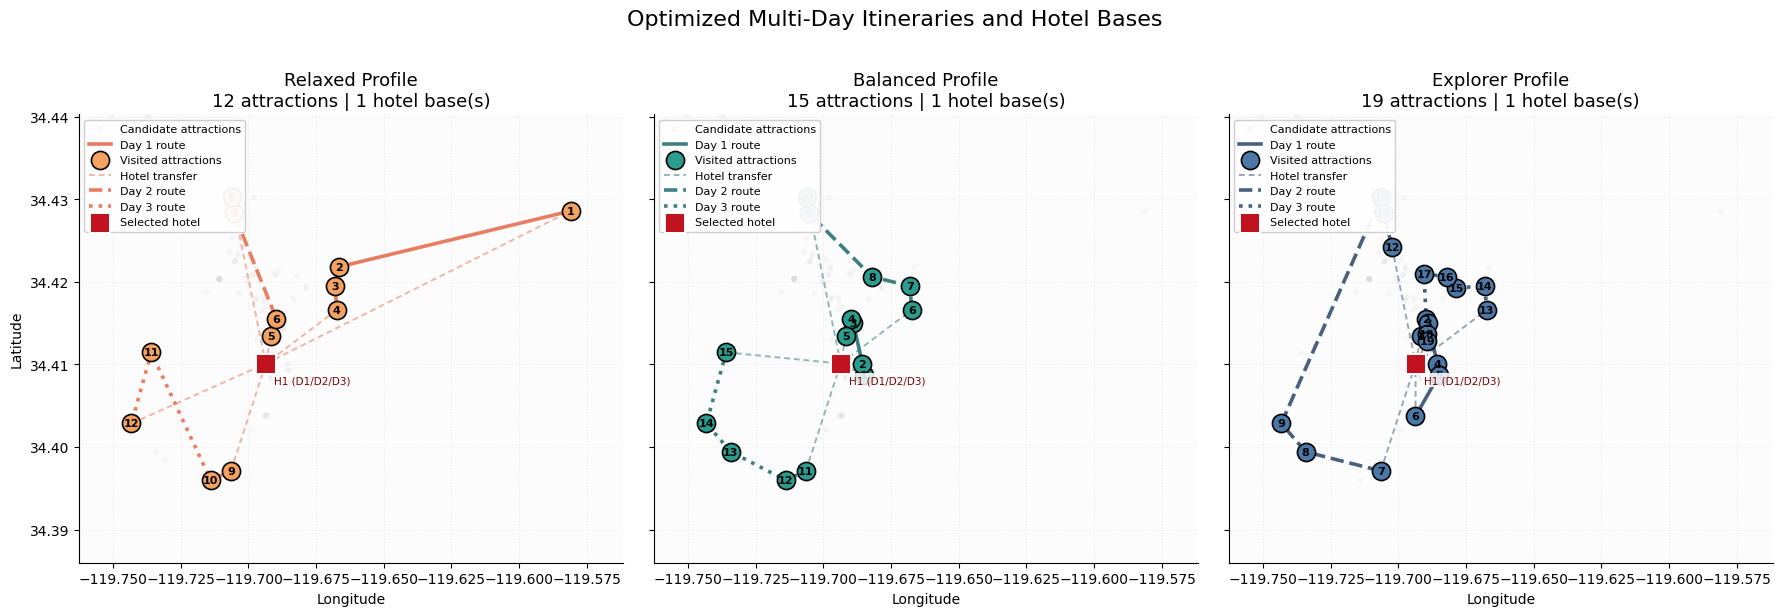

In [98]:
# Section 9.1: Helper function - Reconstruct route from edge list

def reconstruct_route(edge_list, start_attraction=None):
    """
    Reconstruct an ordered route from directed edges.

    Args:
        edge_list: List of (i, j) tuples representing directed route edges.
        start_attraction: Optional attraction index for the route start.

    Returns:
        List of attraction indices in visitation order.
    """
    if not edge_list:
        return [start_attraction] if start_attraction is not None else []

    graph = {}
    for i, j in edge_list:
        graph.setdefault(i, []).append(j)

    current = start_attraction if start_attraction is not None else edge_list[0][0]
    route = []
    visited = set()

    while current is not None and current not in visited:
        route.append(current)
        visited.add(current)
        next_nodes = graph.get(current, [])
        current = next_nodes[0] if next_nodes else None

    return route


def get_day_route_sequence(profile, day_idx):
    """Recover the ordered attraction sequence for one profile and one day."""
    if profile not in route_details:
        return []

    day_nodes = route_details[profile]['selected_by_day'].get(day_idx, [])
    if not day_nodes:
        return []

    start_edges = route_details[profile]['start_edges_by_day'].get(day_idx, [])
    start_attr = start_edges[0][1] if start_edges else day_nodes[0]
    day_edges = route_details[profile]['travel_edges_by_day'].get(day_idx, [])
    graph = {i: j for i, j in day_edges}
    ordered_route = []
    current = start_attr
    visited = set()

    while current is not None and current not in visited:
        ordered_route.append(current)
        visited.add(current)
        current = graph.get(current)

    for node in day_nodes:
        if node not in ordered_route:
            ordered_route.append(node)

    return ordered_route

print("\u2713 Route reconstruction function defined")

# Section 9.2: Visualize optimized routes by profile

import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

profile_styles = {
    'relaxed': {'fill': '#F4A261', 'line': '#E76F51'},
    'balanced': {'fill': '#2A9D8F', 'line': '#287271'},
    'explorer': {'fill': '#4C78A8', 'line': '#355070'},
}
day_styles = ['-', '--', ':']
profile_names = list(TOURIST_PROFILES.keys())

plot_frames = []
for profile in profile_names:
    if profile not in routes or not routes[profile]:
        continue
    plot_frames.append(top100_with_waiting_time.iloc[routes[profile]][['longitude', 'latitude']])
    if profile in route_details:
        used_hotels = [h for h in route_details[profile]['hotels_by_day'].values() if h is not None]
        if used_hotels:
            plot_frames.append(hotels_df.iloc[sorted(set(used_hotels))][['longitude', 'latitude']])

if plot_frames:
    combined_points = pd.concat(plot_frames, ignore_index=True)
    lon_min, lon_max = combined_points['longitude'].min(), combined_points['longitude'].max()
    lat_min, lat_max = combined_points['latitude'].min(), combined_points['latitude'].max()
    lon_pad = max(0.01, (lon_max - lon_min) * 0.12)
    lat_pad = max(0.01, (lat_max - lat_min) * 0.12)
else:
    lon_min, lon_max = -121.0, -120.5
    lat_min, lat_max = 34.3, 34.6
    lon_pad = lat_pad = 0.01

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for profile_idx, profile in enumerate(profile_names):
    ax = axes[profile_idx]
    ax.set_facecolor('#FCFCFC')
    ax.grid(alpha=0.2, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if profile not in routes or not routes[profile]:
        ax.text(0.5, 0.5, 'No route found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{profile.capitalize()} Profile\nNo Solution')
        ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
        ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
        continue

    style = profile_styles[profile]
    details = route_details.get(profile, {})
    selected = routes[profile]

    ax.scatter(
        top100_with_waiting_time['longitude'],
        top100_with_waiting_time['latitude'],
        s=18,
        c='#D9D9D9',
        alpha=0.18,
        edgecolors='none',
        zorder=0,
        label='Candidate attractions',
    )

    stop_counter = 1
    for d in range(K):
        day_route = get_day_route_sequence(profile, d)
        if not day_route:
            continue

        day_coords = top100_with_waiting_time.iloc[day_route]
        ax.plot(
            day_coords['longitude'],
            day_coords['latitude'],
            color=style['line'],
            linewidth=2.6,
            linestyle=day_styles[d % len(day_styles)],
            alpha=0.9,
            zorder=1,
            label=f'Day {d + 1} route',
        )
        ax.scatter(
            day_coords['longitude'],
            day_coords['latitude'],
            s=170,
            c=style['fill'],
            edgecolor='black',
            linewidth=1.2,
            zorder=3,
            label='Visited attractions' if d == 0 else None,
        )

        for _, row in day_coords.iterrows():
            ax.annotate(
                str(stop_counter),
                (row['longitude'], row['latitude']),
                fontsize=8,
                fontweight='bold',
                ha='center',
                va='center',
                zorder=4,
            )
            stop_counter += 1

        for h, i in details.get('start_edges_by_day', {}).get(d, []):
            hotel_row = hotels_df.iloc[h]
            attr_row = top100_with_waiting_time.iloc[i]
            ax.plot(
                [hotel_row['longitude'], attr_row['longitude']],
                [hotel_row['latitude'], attr_row['latitude']],
                linestyle=(0, (3, 2)),
                color=style['line'],
                alpha=0.5,
                linewidth=1.4,
                zorder=2,
                label='Hotel transfer' if d == 0 else None,
            )

        for i, h in details.get('end_edges_by_day', {}).get(d, []):
            attr_row = top100_with_waiting_time.iloc[i]
            hotel_row = hotels_df.iloc[h]
            ax.plot(
                [attr_row['longitude'], hotel_row['longitude']],
                [attr_row['latitude'], hotel_row['latitude']],
                linestyle=(0, (3, 2)),
                color=style['line'],
                alpha=0.5,
                linewidth=1.4,
                zorder=2,
            )

    hotel_days = {}
    for day_idx, hotel_idx in details.get('hotels_by_day', {}).items():
        if hotel_idx is not None:
            hotel_days.setdefault(hotel_idx, []).append(day_idx + 1)

    for hotel_order, (hotel_idx, days) in enumerate(hotel_days.items(), start=1):
        hotel_row = hotels_df.iloc[hotel_idx]
        day_text = '/'.join(f'D{day}' for day in days)
        ax.scatter(
            hotel_row['longitude'],
            hotel_row['latitude'],
            s=220,
            c='#C1121F',
            marker='s',
            edgecolor='white',
            linewidth=1.4,
            zorder=5,
            label='Selected hotel' if hotel_order == 1 else None,
        )
        ax.annotate(
            f'H{hotel_order} ({day_text})',
            (hotel_row['longitude'], hotel_row['latitude']),
            xytext=(6, -14),
            textcoords='offset points',
            fontsize=7.5,
            color='#7F0000',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85),
            zorder=6,
        )

    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    ax.set_xlabel('Longitude')
    if profile_idx == 0:
        ax.set_ylabel('Latitude')

    ax.set_title(
        f"{profile.capitalize()} Profile\n{len(selected)} attractions | {len(hotel_days)} hotel base(s)",
        fontsize=13,
    )

    handles, labels = ax.get_legend_handles_labels()
    by_label = {}
    for handle, label in zip(handles, labels):
        if label and label not in by_label:
            by_label[label] = handle
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc='upper left',
        fontsize=8,
        frameon=True,
        facecolor='white',
        framealpha=0.95,
    )

fig.suptitle('Optimized Multi-Day Itineraries and Hotel Bases', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("results/figures/tourist_routes_static_gurobi.png", dpi=180, bbox_inches='tight')
print("\u2713 Static route visualization saved to results/figures/tourist_routes_static_gurobi.png\n")

plt.show()


In [99]:
for profile_name, details in route_details.items():
    objective_value = details.get('objective_value')
    best_bound = details.get('best_bound')
    status_label = details.get('status', 'UNKNOWN')

    if objective_value is None:
        print(f"{profile_name}: objective value not available")
        continue

    if best_bound is None:
        print(f"{profile_name}: status={status_label}, objective={objective_value:.3f}")
        continue

    relative_gap = abs(objective_value - best_bound) / max(1.0, abs(objective_value))
    print(
        f"{profile_name}: status={status_label}, objective={objective_value:.3f}, "
        f"best_bound={best_bound:.3f}, relative_gap={relative_gap:.2%}"
    )


relaxed: status=TIME_LIMIT, objective=3879.000, best_bound=4360.000, relative_gap=12.40%
balanced: status=TIME_LIMIT, objective=6193.000, best_bound=6999.000, relative_gap=13.01%
explorer: status=TIME_LIMIT, objective=10855.000, best_bound=11429.000, relative_gap=5.29%


In [100]:
for profile_name, details in route_details.items():
    print(f"{profile_name} route edges by day:")
    for day_idx in range(K):
        attr_edges = details.get('travel_edges_by_day', {}).get(day_idx, [])
        start_edges = details.get('start_edges_by_day', {}).get(day_idx, [])
        end_edges = details.get('end_edges_by_day', {}).get(day_idx, [])
        print(f"  Day {day_idx + 1} attraction edges: {attr_edges}")
        print(f"    hotel -> attraction: {start_edges}")
        print(f"    attraction -> hotel: {end_edges}")


relaxed route edges by day:
  Day 1 attraction edges: [(0, 60), (39, 40), (40, 0)]
    hotel -> attraction: [(6, 39)]
    attraction -> hotel: [(60, 6)]
  Day 2 attraction edges: [(9, 56), (23, 9), (56, 51)]
    hotel -> attraction: [(6, 23)]
    attraction -> hotel: [(51, 6)]
  Day 3 attraction edges: [(46, 78), (78, 80), (80, 7)]
    hotel -> attraction: [(6, 46)]
    attraction -> hotel: [(7, 6)]
balanced route edges by day:
  Day 1 attraction edges: [(4, 17), (5, 4), (9, 23), (17, 9)]
    hotel -> attraction: [(6, 5)]
    attraction -> hotel: [(23, 6)]
  Day 2 attraction edges: [(0, 10), (10, 56), (56, 51), (60, 0)]
    hotel -> attraction: [(6, 60)]
    attraction -> hotel: [(51, 6)]
  Day 3 attraction edges: [(7, 80), (18, 7), (46, 78), (78, 18)]
    hotel -> attraction: [(6, 46)]
    attraction -> hotel: [(80, 6)]
explorer route edges by day:
  Day 1 attraction edges: [(4, 5), (5, 32), (9, 17), (17, 4), (23, 9)]
    hotel -> attraction: [(6, 23)]
    attraction -> hotel: [(32, 6

In [101]:
# Section 9.5: Summarize normalized utility and waiting terms by profile

if 'utility_norm' not in globals() or 'waiting_time_norm' not in globals():
    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()
    utility_norm = scaler.fit_transform(top100_with_waiting_time['utility'].to_numpy().reshape(-1, 1)).flatten()
    waiting_time_norm = scaler.fit_transform(top100_with_waiting_time['waiting_final'].to_numpy().reshape(-1, 1)).flatten()
    print('Rebuilt utility_norm and waiting_time_norm from top100_with_waiting_time')

for profile_name, selected_indices in routes.items():
    if not selected_indices:
        print(f"{profile_name}: no selected attractions")
        continue

    utility_gain = sum(float(utility_norm[i]) for i in selected_indices)
    waiting_penalty = sum(float(waiting_time_norm[i]) for i in selected_indices)
    print(
        f"{profile_name}: attractions={len(selected_indices)}, "
        f"utility={utility_gain:.3f}, waiting_penalty={waiting_penalty:.3f}"
    )


relaxed: attractions=12, utility=7.101, waiting_penalty=0.552
balanced: attractions=15, utility=10.182, waiting_penalty=1.649
explorer: attractions=19, utility=13.272, waiting_penalty=2.744


## 9. Interactive Route Map

In [102]:
import openrouteservice

client = openrouteservice.Client(
    key="eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6ImM1ZDk5NDRlMTI3ZDQzOTJhNGQ3MzRjNGI1ZDJlMGQyIiwiaCI6Im11cm11cjY0In0=",
    timeout=20,
    retry_timeout=5,
    retry_over_query_limit=False,
)


In [103]:
def get_route(coordinates, profile_order=("foot-walking", "driving-car"), search_radius=2000):

    if len(coordinates) < 2:
        return coordinates

    radiuses = [search_radius] * len(coordinates)
    last_error = None

    for profile_name in profile_order:
        try:
            route = client.directions(
                coordinates=coordinates,
                profile=profile_name,
                format='geojson',
                radiuses=radiuses,
            )
            geometry = route['features'][0]['geometry']['coordinates']
            return geometry, profile_name
        except Exception as exc:
            last_error = exc

    raise last_error


In [104]:
def reconstruct_route(edge_list, start_attraction=None):

    if not edge_list:
        return [start_attraction] if start_attraction is not None else []

    next_node = {i: j for i, j in edge_list}
    start = start_attraction if start_attraction is not None else edge_list[0][0]

    route = []
    current = start
    visited = set()

    while current is not None and current not in visited:
        route.append(current)
        visited.add(current)
        current = next_node.get(current)

    return route


In [105]:
# Section 10.1: Import libraries and define color schemes

import folium
from folium import plugins
import json
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/cache", exist_ok=True)

COLOR_SCHEME = {
    "relaxed": {"main": "#F4A261", "route": "#E76F51"},
    "balanced": {"main": "#2A9D8F", "route": "#287271"},
    "explorer": {"main": "#4C78A8", "route": "#355070"},
    "hotel": "#C1121F",
    "candidate_hotel": "lightgray",
    "move": "#6C757D",
}
PROFILE_TEXT = {
    "relaxed": "slow-paced",
    "balanced": "moderate",
    "explorer": "comprehensive",
}
OUTING_STYLES = {
    0: {"label": "Outing 1", "dash": [18, 10], "depart_dash": [4, 16], "return_dash": [14, 6], "opacity": 0.95, "pulse": "#FFFFFF", "depart_pulse": "#FFF4CC", "return_pulse": "#FFD6A5"},
    1: {"label": "Outing 2", "dash": [10, 16], "depart_dash": [8, 18], "return_dash": [18, 8], "opacity": 0.82, "pulse": "#FDF0D5", "depart_pulse": "#D9F0C7", "return_pulse": "#B8E1DD"},
    2: {"label": "Outing 3", "dash": [4, 18], "depart_dash": [12, 20], "return_dash": [20, 10], "opacity": 0.70, "pulse": "#E0FBFC", "depart_pulse": "#DEE2FF", "return_pulse": "#DCCCF0"},
}
ROUTE_CACHE_PATH = "results/cache/road_route_cache.json"

if os.path.exists(ROUTE_CACHE_PATH):
    with open(ROUTE_CACHE_PATH, "r", encoding="utf-8") as f:
        route_geometry_cache = json.load(f)
else:
    route_geometry_cache = {}

route_cache_updated = False
route_warning_shown = False

print("\u2713 Libraries, color schemes, and route cache loaded")

# Section 10.2: Helper functions for outing sequences and route geometry

def get_outing_sequence(profile, outing_idx):
    if profile not in route_details:
        return []

    outing_nodes = route_details[profile]['selected_by_day'].get(outing_idx, [])
    if not outing_nodes:
        return []

    start_edges = route_details[profile]['start_edges_by_day'].get(outing_idx, [])
    start_attr = start_edges[0][1] if start_edges else outing_nodes[0]
    outing_edges = route_details[profile]['travel_edges_by_day'].get(outing_idx, [])
    graph = {i: j for i, j in outing_edges}
    ordered_route = []
    current = start_attr
    visited = set()

    while current is not None and current not in visited:
        ordered_route.append(current)
        visited.add(current)
        current = graph.get(current)

    for node in outing_nodes:
        if node not in ordered_route:
            ordered_route.append(node)

    return ordered_route


def get_outing_hotel_indices(details, outing_idx):
    start_edges = details.get('start_edges_by_day', {}).get(outing_idx, [])
    end_edges = details.get('end_edges_by_day', {}).get(outing_idx, [])
    default_hotel = details.get('hotels_by_day', {}).get(outing_idx)

    start_hotel_idx = start_edges[0][0] if start_edges else default_hotel
    end_hotel_idx = end_edges[0][1] if end_edges else start_hotel_idx
    return start_hotel_idx, end_hotel_idx


def normalize_heat_weights(values):
    values = np.asarray(values, dtype=float)
    if np.allclose(values.max(), values.min()):
        return np.full(values.shape, 0.7)
    scaled = (values - values.min()) / (values.max() - values.min())
    return 0.25 + 0.75 * scaled


def route_cache_key(point_sequence, cache_tag):
    points = '|'.join(f"{lat:.6f},{lon:.6f}" for lat, lon in point_sequence)
    return f"{cache_tag}:{points}"


def fetch_routed_path(point_sequence, cache_tag):
    global route_cache_updated, route_warning_shown

    if len(point_sequence) <= 1:
        return point_sequence, 'static'

    key = route_cache_key(point_sequence, cache_tag)
    cached_value = route_geometry_cache.get(key)
    if isinstance(cached_value, dict):
        return cached_value.get('path', point_sequence), cached_value.get('mode', 'cached')
    if cached_value is not None:
        return cached_value, 'cached'

    routed_path = point_sequence
    route_mode = 'straight-line'
    route_fetcher = globals().get('get_route')
    ors_coordinates = [(lon, lat) for lat, lon in point_sequence]

    if callable(route_fetcher):
        try:
            ors_geometry, route_profile = route_fetcher(ors_coordinates)
            converted = [[lat, lon] for lon, lat in ors_geometry]
            if len(converted) >= 2:
                routed_path = converted
                route_mode = route_profile
        except Exception as exc:
            if not route_warning_shown:
                print(f"  ! Road-shape routing failed for some outings ({exc}). Falling back to straight lines where needed.")
                route_warning_shown = True
    elif not route_warning_shown:
        print("  ! `get_route(...)` is not available, so the map will use straight-line segments.")
        route_warning_shown = True

    route_geometry_cache[key] = {'path': routed_path, 'mode': route_mode}
    route_cache_updated = True
    return routed_path, route_mode


def format_route_mode(route_mode):
    mode_map = {
        'foot-walking': 'walking',
        'driving-car': 'driving',
        'straight-line': 'straight-line fallback',
        'cached': 'cached route',
        'static': 'single-point stop',
    }
    return mode_map.get(route_mode, str(route_mode).replace('-', ' '))


def add_outing_badge(feature_group, point, outing_label, color):
    badge_html = f"""
    <div style='
        background:{color};
        color:white;
        border:2px solid white;
        border-radius:14px;
        font-size:10px;
        font-weight:700;
        padding:2px 7px;
        box-shadow:0 1px 6px rgba(0,0,0,0.35);
        white-space:nowrap;'>
        {outing_label}
    </div>
    """
    folium.Marker(
        location=point,
        icon=folium.DivIcon(html=badge_html),
    ).add_to(feature_group)

print("\u2713 Outing and routing helpers ready")

# Section 10.3: Initialize map and base layers

center_lat = (top100_with_waiting_time["latitude"].mean() + hotels_df["latitude"].mean()) / 2
center_lon = (top100_with_waiting_time["longitude"].mean() + hotels_df["longitude"].mean()) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles=None,
    control_scale=True,
    prefer_canvas=True,
)

folium.TileLayer("CartoDB Positron", name="Light basemap", control=True, overlay=False, show=True).add_to(m)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap (alt)", control=True, overlay=False, show=False).add_to(m)
plugins.Fullscreen(position="topleft", title="Expand map", title_cancel="Exit full screen").add_to(m)

heat_weights = normalize_heat_weights(top100_with_waiting_time["utility"].values)
heat_data = [
    [row["latitude"], row["longitude"], weight]
    for (_, row), weight in zip(top100_with_waiting_time.iterrows(), heat_weights)
]
heat_layer = folium.FeatureGroup(name="Attraction utility heatmap", show=True)
plugins.HeatMap(
    heat_data,
    radius=34,
    blur=24,
    min_opacity=0.55,
    max_zoom=14,
    gradient={0.25: "#2c7bb6", 0.5: "#abd9e9", 0.7: "#fdae61", 1.0: "#d7191c"},
).add_to(heat_layer)
heat_layer.add_to(m)

print("\u2713 Map initialized with light basemap and visible heatmap layer")

# Section 10.4: Add candidate hotel layer (hidden by default)

hotel_candidates = folium.FeatureGroup(name="Accommodation candidates", show=False)
hotel_cluster = plugins.MarkerCluster(disableClusteringAtZoom=14).add_to(hotel_candidates)

for hotel_idx, hotel_row in hotels_df.iterrows():
    hotel_popup = folium.Popup(
        f"<b>{hotel_row['name']}</b><br/>Type: {hotel_row.get('lodging_type', hotel_row.get('type', 'Hotel'))}<br/>Rating: {hotel_row.get('rating_score', hotel_row.get('stars', 'N/A'))}<br/>Cost Proxy: ${hotel_row.get('nightly_price', 0):.2f}<br/>Price Source: {hotel_row.get('price_source', 'unknown')}",
        max_width=260,
    )

    folium.Marker(
        location=[hotel_row["latitude"], hotel_row["longitude"]],
        popup=hotel_popup,
        tooltip=f"Candidate stay: {hotel_row['name']}",
        icon=folium.Icon(color=COLOR_SCHEME["candidate_hotel"], icon="bed", prefix="fa"),
    ).add_to(hotel_cluster)

hotel_candidates.add_to(m)
print("\u2713 Candidate hotel layer added (hidden by default)")

# Section 10.5: Process and visualize routes for each tourist profile

route_groups = {}
itinerary_control = {}
bounds_points = []

for profile in TOURIST_PROFILES:
    profile_default_show = (profile == "balanced")
    hotel_fg = folium.FeatureGroup(name=f"{profile.capitalize()} hotels", show=profile_default_show, control=False)
    move_fg = folium.FeatureGroup(name=f"{profile.capitalize()} hotel relocations", show=profile_default_show, control=False)
    outing_groups = {}
    outing_labels_present = {}

    if profile not in routes or not routes[profile]:
        print(f"  \u2298 No route for {profile} profile")
        continue

    details = route_details.get(profile, {})
    selected_indices = routes[profile]

    outing_labels = {
        outing_idx: OUTING_STYLES[outing_idx % len(OUTING_STYLES)]["label"]
        for outing_idx in range(K)
    }

    hotel_roles = {}
    for outing_idx in range(K):
        start_hotel_idx, end_hotel_idx = get_outing_hotel_indices(details, outing_idx)
        outing_label = outing_labels[outing_idx]
        if start_hotel_idx is not None:
            hotel_roles.setdefault(start_hotel_idx, {'departures': [], 'returns': []})['departures'].append(outing_label)
        if end_hotel_idx is not None:
            hotel_roles.setdefault(end_hotel_idx, {'departures': [], 'returns': []})['returns'].append(outing_label)

    for hotel_idx, hotel_role in hotel_roles.items():
        hotel_row = hotels_df.iloc[hotel_idx]
        departure_text = ', '.join(hotel_role['departures']) if hotel_role['departures'] else 'None'
        return_text = ', '.join(hotel_role['returns']) if hotel_role['returns'] else 'None'
        hotel_popup = folium.Popup(
            f"<b>{hotel_row['name']}</b><br/>Departure outings: {departure_text}<br/>Return outings: {return_text}<br/>Type: {hotel_row.get('lodging_type', hotel_row.get('type', 'Hotel'))}<br/>Rating: {hotel_row.get('rating_score', hotel_row.get('stars', 'N/A'))}<br/>Estimated nightly price: ${hotel_row.get('nightly_price', 0):.2f}",
            max_width=260,
        )
        folium.Marker(
            location=[hotel_row['latitude'], hotel_row['longitude']],
            popup=hotel_popup,
            tooltip=f"{profile.capitalize()} hotel: {hotel_row['name']} (departures {departure_text}; returns {return_text})",
            icon=folium.Icon(color='darkred', icon='hotel', prefix='fa'),
        ).add_to(hotel_fg)
        bounds_points.append([hotel_row['latitude'], hotel_row['longitude']])

    for outing_idx in range(K):
        outing_route = get_outing_sequence(profile, outing_idx)
        if not outing_route:
            continue

        outing_style = OUTING_STYLES[outing_idx % len(OUTING_STYLES)]
        outing_label = outing_style["label"]
        outing_fg = folium.FeatureGroup(name=f"{profile.capitalize()} {outing_label}", show=profile_default_show, control=False)
        outing_groups[str(outing_idx)] = outing_fg
        outing_labels_present[str(outing_idx)] = outing_label

        start_hotel_idx, end_hotel_idx = get_outing_hotel_indices(details, outing_idx)
        stop_points = []
        outing_stop_names = []

        if start_hotel_idx is not None:
            start_hotel_row = hotels_df.iloc[start_hotel_idx]
            start_hotel_name = start_hotel_row['name']
            start_hotel_point = [start_hotel_row['latitude'], start_hotel_row['longitude']]
        else:
            start_hotel_name = 'selected hotel'
            start_hotel_point = None

        for stop_idx, attr_idx in enumerate(outing_route, start=1):
            attr_row = top100_with_waiting_time.iloc[attr_idx]
            point = [attr_row['latitude'], attr_row['longitude']]
            stop_points.append(point)
            bounds_points.append(point)
            outing_stop_names.append(attr_row['name'])

            popup_text = f"""
            <b>{attr_row['name']}</b><br/>
            Profile: {profile.capitalize()} ({PROFILE_TEXT[profile]})<br/>
            {outing_label}, Stop {stop_idx}<br/>
            Rating: {attr_row['stars']:.1f}/5.0<br/>
            Reviews: {attr_row['review_count']}<br/>
            Utility: {attr_row['utility']:.2f}<br/>
            Wait Time: {attr_row['waiting_final']:.1f} min<br/>
            Duration: {attr_row['visit_duration_sim']:.1f} min<br/>
            Cost: ${attr_row['cost']:.2f}
            """

            folium.CircleMarker(
                location=point,
                radius=7,
                popup=folium.Popup(popup_text, max_width=220, min_width=160),
                color=COLOR_SCHEME[profile]['main'],
                fill=True,
                fillColor=COLOR_SCHEME[profile]['main'],
                fillOpacity=outing_style['opacity'],
                weight=2,
                tooltip=f"{outing_label}, stop {stop_idx}: {attr_row['name']}",
            ).add_to(outing_fg)

        if end_hotel_idx is not None:
            end_hotel_row = hotels_df.iloc[end_hotel_idx]
            end_hotel_name = end_hotel_row['name']
            end_hotel_point = [end_hotel_row['latitude'], end_hotel_row['longitude']]
        else:
            end_hotel_name = start_hotel_name
            end_hotel_point = start_hotel_point

        if stop_points:
            add_outing_badge(outing_fg, stop_points[0], outing_label, COLOR_SCHEME[profile]['route'])

        outing_flow = ' -> '.join([start_hotel_name, *outing_stop_names, end_hotel_name])
        departure_mode_label = 'not used'
        travel_mode_label = 'single-stop outing'
        return_mode_label = 'not used'

        if start_hotel_point is not None and stop_points:
            departure_path, departure_mode = fetch_routed_path(
                [start_hotel_point, stop_points[0]],
                cache_tag=f"hotel_out:{profile}:{outing_idx}",
            )
            departure_mode_label = format_route_mode(departure_mode)
            folium.PolyLine(
                locations=departure_path,
                color=COLOR_SCHEME[profile]['main'],
                weight=2.2,
                opacity=0.28,
                dash_array=','.join(str(x) for x in outing_style['depart_dash']),
                tooltip=f"{profile.capitalize()} {outing_label} hotel departure: {start_hotel_name} -> {outing_stop_names[0]} [{departure_mode_label}]",
            ).add_to(outing_fg)
            plugins.AntPath(
                locations=departure_path,
                color=COLOR_SCHEME[profile]['main'],
                pulse_color=outing_style['depart_pulse'],
                weight=5,
                opacity=min(1.0, outing_style['opacity'] + 0.06),
                delay=650,
                dash_array=outing_style['depart_dash'],
                tooltip=f"{profile.capitalize()} {outing_label} departure animation: leave {start_hotel_name} for {outing_stop_names[0]} [{departure_mode_label}]",
            ).add_to(outing_fg)

        if len(stop_points) >= 2:
            travel_path, travel_mode = fetch_routed_path(
                stop_points,
                cache_tag=f"outing_core:{profile}:{outing_idx}",
            )
            travel_mode_label = format_route_mode(travel_mode)
            folium.PolyLine(
                locations=travel_path,
                color=COLOR_SCHEME[profile]['route'],
                weight=2.8,
                opacity=0.32,
                tooltip=f"{profile.capitalize()} {outing_label} sightseeing route [{travel_mode_label}]",
                dash_array=','.join(str(x) for x in outing_style['dash']),
                popup=folium.Popup(f"<b>{profile.capitalize()} {outing_label}</b><br/>Flow: {outing_flow}<br/>Sightseeing leg mode: {travel_mode_label}", max_width=320),
            ).add_to(outing_fg)
            plugins.AntPath(
                locations=travel_path,
                color=COLOR_SCHEME[profile]['route'],
                pulse_color=outing_style['pulse'],
                weight=5.5,
                opacity=outing_style['opacity'],
                delay=900,
                dash_array=outing_style['dash'],
                tooltip=f"{profile.capitalize()} {outing_label} sightseeing animation: between attractions [{travel_mode_label}]",
            ).add_to(outing_fg)

        if end_hotel_point is not None and stop_points:
            return_path, return_mode = fetch_routed_path(
                [stop_points[-1], end_hotel_point],
                cache_tag=f"hotel_back:{profile}:{outing_idx}",
            )
            return_mode_label = format_route_mode(return_mode)
            folium.PolyLine(
                locations=return_path,
                color=COLOR_SCHEME[profile]['route'],
                weight=2.2,
                opacity=0.30,
                dash_array=','.join(str(x) for x in outing_style['return_dash']),
                tooltip=f"{profile.capitalize()} {outing_label} hotel return: {outing_stop_names[-1]} -> {end_hotel_name} [{return_mode_label}]",
            ).add_to(outing_fg)
            plugins.AntPath(
                locations=return_path,
                color=COLOR_SCHEME[profile]['route'],
                pulse_color=outing_style['return_pulse'],
                weight=4.7,
                opacity=outing_style['opacity'],
                delay=1100,
                dash_array=outing_style['return_dash'],
                tooltip=f"{profile.capitalize()} {outing_label} return animation: back to {end_hotel_name} from {outing_stop_names[-1]} [{return_mode_label}]",
            ).add_to(outing_fg)

        print(
            f"    - {profile.capitalize()} {outing_label}: {outing_flow} | "
            f"depart={departure_mode_label}; sightseeing={travel_mode_label}; return={return_mode_label}"
        )

    for outing_idx, moves in details.get('transitions_by_day', {}).items():
        next_label = outing_labels.get(outing_idx + 1, f"Outing {outing_idx + 2}")
        for h, g in moves:
            if h == g:
                continue
            start_hotel = hotels_df.iloc[h]
            next_hotel = hotels_df.iloc[g]
            folium.PolyLine(
                locations=[[start_hotel['latitude'], start_hotel['longitude']], [next_hotel['latitude'], next_hotel['longitude']]],
                color=COLOR_SCHEME['move'],
                weight=2,
                opacity=0.55,
                dash_array='2, 8',
                tooltip=f"Overnight relocation before {next_label}",
            ).add_to(move_fg)

    for outing_fg in outing_groups.values():
        outing_fg.add_to(m)
    move_fg.add_to(m)
    hotel_fg.add_to(m)

    route_groups[profile] = {
        'hotels': hotel_fg,
        'moves': move_fg,
        'outings': outing_groups,
    }
    itinerary_control[profile] = {
        'default_show': profile_default_show,
        'hotels': hotel_fg.get_name(),
        'moves': move_fg.get_name(),
        'outings': {outing_key: layer.get_name() for outing_key, layer in outing_groups.items()},
        'labels': outing_labels_present,
    }
    print(f"  \u2713 {profile.capitalize()} itinerary added ({len(selected_indices)} attractions, {len(hotel_roles)} hotel base(s), {len(outing_groups)} outing layer(s))")

if bounds_points:
    m.fit_bounds(bounds_points, padding=(25, 25))

if route_cache_updated:
    with open(ROUTE_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(route_geometry_cache, f)
    print(f"\u2713 Route geometry cache updated: {ROUTE_CACHE_PATH}")

# Section 10.6: Add layer control, itinerary selector, and legend

folium.LayerControl(position="topright", collapsed=False).add_to(m)

panel_sections = []
for profile in TOURIST_PROFILES:
    control_info = itinerary_control.get(profile)
    if not control_info:
        continue

    default_checked = 'checked' if control_info['default_show'] else ''
    default_display = 'block' if control_info['default_show'] else 'none'
    day_rows = []
    for outing_key, outing_label in control_info['labels'].items():
        day_checked = 'checked' if control_info['default_show'] else ''
        day_rows.append(
            f"<label class='itinerary-day-label'><input type='checkbox' id='day-toggle-{profile}-{outing_key}' {day_checked}> {outing_label}</label>"
        )

    panel_sections.append(
        f"""
        <div class='itinerary-profile-block'>
            <label class='itinerary-profile-label'>
                <input type='checkbox' id='profile-toggle-{profile}' {default_checked}>
                <span class='profile-swatch' style='background:{COLOR_SCHEME[profile]['main']};'></span>
                {profile.capitalize()} itinerary
            </label>
            <div id='days-{profile}' class='itinerary-day-group' style='display:{default_display};'>
                {''.join(day_rows)}
            </div>
        </div>
        """
    )

panel_html = f"""
<style>
#itinerary-panel {{
    position: fixed;
    top: 170px;
    right: 18px;
    width: 250px;
    background: rgba(255, 255, 255, 0.96);
    border: 1px solid #CFCFCF;
    border-radius: 8px;
    box-shadow: 0 2px 10px rgba(0, 0, 0, 0.15);
    z-index: 9998;
    font-size: 12px;
    padding: 12px 14px;
    line-height: 1.4;
}}
#itinerary-panel .itinerary-title {{
    font-weight: 700;
    margin-bottom: 4px;
}}
#itinerary-panel .itinerary-subtitle {{
    color: #5c5c5c;
    margin-bottom: 10px;
}}
#itinerary-panel .itinerary-profile-block + .itinerary-profile-block {{
    margin-top: 8px;
    padding-top: 8px;
    border-top: 1px solid #ECECEC;
}}
#itinerary-panel .itinerary-profile-label {{
    display: flex;
    align-items: center;
    gap: 7px;
    font-weight: 600;
    cursor: pointer;
}}
#itinerary-panel .profile-swatch {{
    width: 10px;
    height: 10px;
    border-radius: 50%;
    display: inline-block;
}}
#itinerary-panel .itinerary-day-group {{
    margin-left: 24px;
    margin-top: 6px;
}}
#itinerary-panel .itinerary-day-label {{
    display: block;
    margin-top: 4px;
    cursor: pointer;
}}
#itinerary-panel .itinerary-day-label.day-disabled {{
    opacity: 0.55;
}}
</style>
<div id='itinerary-panel'>
    <div class='itinerary-title'>Itinerary Selector</div>
    <div class='itinerary-subtitle'>Turn on a profile to reveal outing checkboxes.</div>
    {''.join(panel_sections)}
</div>
"""
m.get_root().html.add_child(folium.Element(panel_html))

layer_registry_parts = []
for profile in TOURIST_PROFILES:
    control_info = itinerary_control.get(profile)
    if not control_info:
        continue
    outing_parts = [f"'{outing_key}': '{layer_name}'" for outing_key, layer_name in control_info['outings'].items()]
    layer_registry_parts.append(
        f"'{profile}': {{hotels: '{control_info['hotels']}', moves: '{control_info['moves']}', outings: {{{', '.join(outing_parts)}}}}}"
    )

itinerary_state = {
    profile: {
        'enabled': control_info['default_show'],
        'outings': {
            outing_key: control_info['default_show']
            for outing_key in control_info['outings']
        },
    }
    for profile, control_info in itinerary_control.items()
}

control_js = f"""
var itineraryMapName = '{m.get_name()}';
var itineraryLayerNames = {{
    {', '.join(layer_registry_parts)}
}};
var itineraryState = {json.dumps(itinerary_state)};
var itineraryControlsBound = false;

function resolveItineraryMap() {{
    return window[itineraryMapName] || null;
}}

function resolveLayer(layerName) {{
    if (!layerName) {{
        return null;
    }}
    return window[layerName] || null;
}}

function setLayerVisibility(layerName, shouldShow) {{
    var mapObject = resolveItineraryMap();
    var layerObject = resolveLayer(layerName);
    if (!mapObject || !layerObject) {{
        return false;
    }}
    if (shouldShow) {{
        if (!mapObject.hasLayer(layerObject)) {{
            mapObject.addLayer(layerObject);
        }}
    }} else if (mapObject.hasLayer(layerObject)) {{
        mapObject.removeLayer(layerObject);
    }}
    return true;
}}

function syncProfileVisibility(profileKey) {{
    var state = itineraryState[profileKey];
    var layers = itineraryLayerNames[profileKey];
    var dayGroup = document.getElementById('days-' + profileKey);

    if (!state || !layers) {{
        return;
    }}

    if (dayGroup) {{
        dayGroup.style.display = state.enabled ? 'block' : 'none';
    }}

    setLayerVisibility(layers.hotels, state.enabled);
    setLayerVisibility(layers.moves, state.enabled);

    Object.keys(layers.outings).forEach(function(outingKey) {{
        var outingToggle = document.getElementById('day-toggle-' + profileKey + '-' + outingKey);
        var shouldShowOuting = state.enabled && state.outings[outingKey];
        if (outingToggle) {{
            outingToggle.disabled = !state.enabled;
            if (outingToggle.parentElement) {{
                outingToggle.parentElement.classList.toggle('day-disabled', !state.enabled);
            }}
        }}
        setLayerVisibility(layers.outings[outingKey], shouldShowOuting);
    }});
}}

function bindProfileControl(profileKey) {{
    var profileToggle = document.getElementById('profile-toggle-' + profileKey);
    var layerInfo = itineraryLayerNames[profileKey];
    if (!profileToggle || !layerInfo) {{
        return;
    }}

    profileToggle.addEventListener('change', function() {{
        itineraryState[profileKey].enabled = this.checked;
        if (this.checked) {{
            var anyVisible = Object.keys(itineraryState[profileKey].outings).some(function(outingKey) {{
                return itineraryState[profileKey].outings[outingKey];
            }});
            if (!anyVisible) {{
                Object.keys(itineraryState[profileKey].outings).forEach(function(outingKey) {{
                    itineraryState[profileKey].outings[outingKey] = true;
                    var outingToggle = document.getElementById('day-toggle-' + profileKey + '-' + outingKey);
                    if (outingToggle) {{
                        outingToggle.checked = true;
                    }}
                }});
            }}
        }}
        syncProfileVisibility(profileKey);
    }});

    Object.keys(layerInfo.outings).forEach(function(outingKey) {{
        var outingToggle = document.getElementById('day-toggle-' + profileKey + '-' + outingKey);
        if (!outingToggle) {{
            return;
        }}
        outingToggle.addEventListener('change', function() {{
            itineraryState[profileKey].outings[outingKey] = this.checked;
            syncProfileVisibility(profileKey);
        }});
    }});

    syncProfileVisibility(profileKey);
}}

function initializeItineraryControl(attempt) {{
    if (itineraryControlsBound) {{
        return;
    }}

    var mapObject = resolveItineraryMap();
    if (!mapObject) {{
        if (attempt < 40) {{
            window.setTimeout(function() {{ initializeItineraryControl(attempt + 1); }}, 150);
        }}
        return;
    }}

    var allLayersReady = Object.keys(itineraryLayerNames).every(function(profileKey) {{
        var layerInfo = itineraryLayerNames[profileKey];
        if (!resolveLayer(layerInfo.hotels) || !resolveLayer(layerInfo.moves)) {{
            return false;
        }}
        return Object.keys(layerInfo.outings).every(function(outingKey) {{
            return !!resolveLayer(layerInfo.outings[outingKey]);
        }});
    }});

    if (!allLayersReady) {{
        if (attempt < 40) {{
            window.setTimeout(function() {{ initializeItineraryControl(attempt + 1); }}, 150);
        }}
        return;
    }}

    itineraryControlsBound = true;
    Object.keys(itineraryLayerNames).forEach(bindProfileControl);
}}

window.setTimeout(function() {{
    initializeItineraryControl(0);
}}, 0);
"""
m.get_root().script.add_child(folium.Element(control_js))

legend_html = """
<div style="position: fixed;
     bottom: 18px; left: 18px; width: 295px; height: auto;
     background: rgba(255, 255, 255, 0.95); border: 1px solid #CFCFCF; border-radius: 8px;
     box-shadow: 0 2px 10px rgba(0, 0, 0, 0.15); z-index: 9999;
     font-size: 12px; padding: 12px 14px; line-height: 1.45;">
<div style="font-weight: 700; margin-bottom: 8px;">Route Layers</div>
<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:#F4A261;margin-right:8px;"></span>Relaxed itinerary</div>
<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:#2A9D8F;margin-right:8px;"></span>Balanced itinerary</div>
<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:#4C78A8;margin-right:8px;"></span>Explorer itinerary</div>
<div style="margin-top: 8px;"><span style="display:inline-block;width:12px;height:12px;background:#C1121F;margin-right:8px;"></span>Selected hotel</div>
<div><span style="display:inline-block;width:16px;border-top:2px dashed #6C757D;margin-right:8px;vertical-align:middle;"></span>Overnight relocation</div>
<div><span style="display:inline-block;width:16px;border-top:3px dashed #F4A261;margin-right:8px;vertical-align:middle;"></span>Animated hotel departure</div>
<div><span style="display:inline-block;width:16px;border-top:3px dotted #355070;margin-right:8px;vertical-align:middle;"></span>Animated hotel return</div>
<div><span style="display:inline-block;width:16px;border-top:3px solid #287271;margin-right:8px;vertical-align:middle;"></span>Animated sightseeing route</div>
<div style="margin-top: 8px;"><span style="display:inline-block;padding:1px 6px;border-radius:10px;background:#555;color:white;margin-right:8px;">Outing 1/2/3</span>Flexible outing labels instead of fixed calendar days</div>
<div><span style="display:inline-block;width:16px;height:10px;background:linear-gradient(90deg, #2c7bb6, #abd9e9, #fdae61, #d7191c);margin-right:8px;vertical-align:middle;"></span>Utility heatmap</div>
<div style="margin-top: 8px; color: #555;">Use the Itinerary Selector on the right to expand a profile and toggle each outing separately.</div>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

print("\u2713 Layer control, itinerary selector, and legend added")

# Section 10.7: Save and display interactive map

output_path = "results/figures/tourist_routes_map_gurobi.html"
m.save(output_path)
print(f"\u2713 Interactive map saved to {output_path}")
print("  Tip: if tiles are still blocked in a local file tab, run `python -m http.server` from the project root and open http://localhost:8000/results/figures/tourist_routes_map_gurobi.html")

m


✓ Libraries, color schemes, and route cache loaded
✓ Outing and routing helpers ready
✓ Map initialized with light basemap and visible heatmap layer
✓ Candidate hotel layer added (hidden by default)
    - Relaxed Outing 1: Harbor House Inn -> Santa Barbara Beach Horseback Rides -> Santa Barbara Sunrise RV Park -> Santa Barbara Zoo -> East Beach -> Harbor House Inn | depart=walking; sightseeing=walking; return=walking
    - Relaxed Outing 2: Harbor House Inn -> MOXI - The Wolf Museum Of Exploration + Innovation -> SB Buggie -> Alameda Park -> Alice Keck Park Memorial Gardens -> Harbor House Inn | depart=walking; sightseeing=walking; return=walking
    - Relaxed Outing 3: Harbor House Inn -> Shoreline Park -> One Thousand Steps Beach -> Elings Park -> Arroyo Burro Beach -> Harbor House Inn | depart=walking; sightseeing=walking; return=walking
  ✓ Relaxed itinerary added (12 attractions, 1 hotel base(s), 3 outing layer(s))
    - Balanced Outing 1: Harbor House Inn -> Celebration Cruises -

## Sensitivity Analysis

The optimization model exposes four key objective trade-off parameters:

- `alpha`: congestion / waiting-time penalty
- `beta`: travel-time penalty
- `gamma`: monetary cost penalty
- `lambda`: profile-level exploration bonus in the current implementation

The sweep below varies one parameter at a time around the baseline configuration and records:

- total attraction utility
- total waiting time
- total travel distance
- diversity score

Note: in this notebook, content diversity is still shaped by the theme-repeat penalties in the solver. The `lambda` sweep is mapped to the existing `attraction_bonus` term so we can study how stronger exploration incentives change the itinerary.


In [ ]:
# Sensitivity analysis helper import and default grid

import importlib
import matplotlib.pyplot as plt
import sensitivity_analysis

importlib.reload(sensitivity_analysis)

MODEL_SETTINGS = optimizer_outputs.get("model_settings", {})
SENSITIVITY_PROFILE = "balanced"
SENSITIVITY_GRID = sensitivity_analysis.build_default_parameter_grid(
    globals(),
    profile_name=SENSITIVITY_PROFILE,
)

SENSITIVITY_GRID


In [ ]:
# Run one-at-a-time parameter sweeps and save the tabular results

SENSITIVITY_RESULTS_PATH = "results/outputs/sensitivity_analysis_balanced.csv"

sensitivity_df = sensitivity_analysis.run_parameter_sweep(
    globals(),
    profile_name=SENSITIVITY_PROFILE,
    parameter_values=SENSITIVITY_GRID,
    solver_overrides={"time_limit_seconds": 90.0, "mip_gap_target": 0.05},
    save_path=SENSITIVITY_RESULTS_PATH,
    show_progress=True,
)

print(f"Saved sensitivity results to {SENSITIVITY_RESULTS_PATH}")
sensitivity_df[
    [
        "parameter_name",
        "parameter_value",
        "is_baseline",
        "selected_attractions",
        "total_attraction_utility",
        "total_waiting_time",
        "total_travel_distance_km",
        "diversity_score",
        "objective_value",
        "status",
        "mip_gap",
    ]
]


In [ ]:
# Plot a 2x2 metric dashboard for each parameter

for parameter_name in sensitivity_analysis.PARAMETER_ORDER:
    if parameter_name not in sensitivity_df["parameter_name"].unique():
        continue
    sensitivity_analysis.plot_parameter_sensitivity(sensitivity_df, parameter_name)
    plt.show()


## Broader Impact

This framework demonstrates how machine learning predictions and optimization can support smarter urban tourism planning. Potential applications include personalized travel planning platforms, tourism demand management, smart city infrastructure planning, and congestion-aware tourism recommendation systems.

More broadly, the project shows how predictive models can be integrated with optimization to support complex real-world decision making.

## Future Work

Natural next extensions include multi-city and seasonal scenario testing, stronger traveler-personalization, live traffic or weather re-optimization, richer uncertainty modeling, and production deployment through an API or interactive planning dashboard.
